<a href="https://colab.research.google.com/github/lloppy/urfu_neironki-5sem/blob/main/model_chemistry_gen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [50]:
!pip install openpyxl

In [51]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


Экселька долго читалась, поэтому перевела в csv формат.

Csv тоже догло считывается, потому что сам файл весит 88 Мб

In [52]:
from google.colab import files
uploaded = files.upload()

Saving gen_info.csv to gen_info (1).csv


In [53]:
df_raw = pd.read_csv('gen_info.csv', header=0, index_col=0)
df = df_raw.T
df.tail()

<ipython-input-53-e4632de2c4e4>:1: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,26

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,27,0,0,0,270,0,14,16,no
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,24,0,0,0,282,0,8,24,no
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,40,0,1,0,437,0,4,31,no
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,20,0,0,0,317,0,3,31,no
TCGA-G9-6370-01A-11R-1789-07,6753,26,1400,990,175,326,3165,1849,4514,1909,...,0,6,0,0,0,434,0,2,27,no


In [54]:
# Проверка первых нескольких строк DataFrame
print("\Последние строки DataFrame после удаления первой строки:\n", df.tail())

# Преобразование значений 'reccurence' в 0 и 1
df['reccurence_numeric'] = df['reccurence'].map({'no': 0, 'yes': 1})

# Проверка уникальных значений в столбце 'reccurence'
print("\nУникальные значения в столбце 'reccurence':\n", df['reccurence'].unique())

# Проверка уникальных значений в столбце 'reccurence_numeric'
print("\nУникальные значения в столбце 'reccurence_numeric':\n", df['reccurence_numeric'].unique())

# Проверка результата
print("\nПервые строки с новым столбцом 'reccurence_numeric':\n", df[['reccurence', 'reccurence_numeric']].head())

\Последние строки DataFrame после удаления первой строки:
                              ENSG00000000003.15 ENSG00000000005.6  \
TCGA-J4-AATV-01A-11R-A41O-07               3115                60   
TCGA-HC-8266-01A-11R-2263-07               4699                14   
TCGA-HC-8262-01A-11R-2263-07               4835                 0   
TCGA-EJ-7797-01A-11R-2263-07               4222                 5   
TCGA-G9-6370-01A-11R-1789-07               6753                26   

                             ENSG00000000419.13 ENSG00000000457.14  \
TCGA-J4-AATV-01A-11R-A41O-07               1393                735   
TCGA-HC-8266-01A-11R-2263-07               1575               1003   
TCGA-HC-8262-01A-11R-2263-07               2073               1763   
TCGA-EJ-7797-01A-11R-2263-07               1214               1425   
TCGA-G9-6370-01A-11R-1789-07               1400                990   

                             ENSG00000000460.17 ENSG00000000938.13  \
TCGA-J4-AATV-01A-11R-A41O-07       

In [55]:
df.drop(columns="reccurence", inplace=True)
df.tail()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence_numeric
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,27,0,0,0,270,0,14,16,0
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,24,0,0,0,282,0,8,24,0
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,40,0,1,0,437,0,4,31,0
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,20,0,0,0,317,0,3,31,0
TCGA-G9-6370-01A-11R-1789-07,6753,26,1400,990,175,326,3165,1849,4514,1909,...,0,6,0,0,0,434,0,2,27,0


### Структура датасета

1. **Индексы и идентификаторы**:
   - **Колонки датасета**: идентификаторы генов (например, `ENSG00000000003.15`), которые представляют собой уникальные коды для каждого гена в базе данных Ensembl. Эти коды используются для идентификации генов в геномных исследованиях.

2. **Столбец `reccurence`**:
   - Этот столбец обозначает наличие рецидива заболевания у пациента. Значения могут быть "yes/1" или "no/0", что указывает на то, произошел ли рецидив рака после лечения.


Расшифровку по генам можно посмотреть здесь: https://www.ensembl.org/index.html



In [56]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
Index: 554 entries, TCGA-HC-A6AP-01A-11R-A30B-07 to TCGA-G9-6370-01A-11R-1789-07
Columns: 60661 entries, ENSG00000000003.15 to reccurence_numeric
dtypes: int64(1), object(60660)
memory usage: 256.4+ MB
None


Датасет содержит 554 записей (строк)

Датасет имеет 60661 столбец и занимает более 256.4 МБ памяти



In [57]:
missing_values = df.isnull().sum()
print("Пропуски в данных:\n", missing_values[missing_values > 0])

Пропуски в данных:
 Series([], dtype: int64)


В датасете нет пропущенных значений. Все ячейки заполнены данными

## Рассмотрим подробно кажое значение в датасете

<br>

|           | TCGA-HC-A6AP-01A-11R-A30B-07 | TCGA-KK-A7B2-01A-12R-A32O-07 | TCGA-EJ-A8FO-01A-21R-A36G-07 | TCGA-G9-6377-01A-11R-1965-07 |
| :------------------------- | :------------------------------- | :--------------------------- | :--------------------------- | :--------------------------- |
| **ENSG00000000003.15** | 4158                         | 2637                         | 4429                         | 4314                         |
| **ENSG00000000005.6**      | 138                              | 2                            | 2                            | 5                            |
| **ENSG00000000419.13**     | 1571                             | 1436                         | 1765                         | 1454                         |
| **ENSG00000000457.14**     | 379                              | 452                          | 1069                         | 845                          |
| **ENSG00000000460.17**     | 140                              | 123                          | 183                          | 149                          |

<br>

#### 1. Идентификатор образца: TCGA-HC-A6AP-01A-11R-A30B-07

Этот идентификатор следует формату, используемому проектом TCGA (The Cancer Genome Atlas). Он состоит из нескольких частей, каждая из которых имеет свое значение:

- **TCGA**: Указывает на проект TCGA, который занимается сбором и анализом геномных данных рака (проверить у всех ли одинаковый, и вырезать)
- **HC**: Сайт начала транскрипции (TSS) — это конкретное место на ДНК, где начинается транскрипция РНК. Он определяется как первый нуклеотид РНК-транскрипта, который синтезируется с ДНК-шаблона. Определение TSS имеет важное значение для понимания экспрессии и регуляции генов, так как он обозначает начало кодирующей области для гена.
- **A6AP**: Уникальный идентификатор образца, который может включать информацию о конкретной пробе или пациенте (посмотреть какие были еще пробы, и сколько всего таких проб было)
- **01A**: Указывает на тип образца. "01" может означать первичный образец, а "A" может указывать на его статус (например, нормальный или опухолевый) (разделить на нормальный и опухолевый - соотнести с reccurence)

-  **11R**: Указывает на тип анализа или обработку образца. "R" может обозначать рецидив или другой статус.
 - **A30B**: Дополнительные идентификаторы, которые могут указывать на конкретные характеристики образца или его обработку.
 - **07**: Номер версии

#### 2. Идентификатор гена: ENSG00000000003.15

Этот идентификатор соответствует базе данных Ensembl и обозначает конкретный ген:

- **ENSG**: указывает на то, что это идентификатор гена в Ensembl (European Nucleotide Archive).
- **00000000003**: Уникальный номер гена.
- **.15**: Версия аннотации гена. Это указывает на то, что существует несколько версий аннотации для этого гена.

#### 3. Числовое значение: 4158

- **Уровень экспрессии гена**: если это значение связано с геном (например, `ENSG00000000003.15`), оно может представлять уровень экспрессии этого гена в образце (например, количество РНК или белка).


In [58]:
print(df.columns)

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14',
       ...
       'ENSG00000288662.1', 'ENSG00000288663.1', 'ENSG00000288665.1',
       'ENSG00000288667.1', 'ENSG00000288669.1', 'ENSG00000288670.1',
       'ENSG00000288671.1', 'ENSG00000288674.1', 'ENSG00000288675.1',
       'reccurence_numeric'],
      dtype='object', length=60661)


# 1. Идентификатор образца (Sample_ID)

## Identifiers TCGA-XX-XXXXX-XXX-XXX-XXXX-XX

In [59]:
# 1. Проверка, все ли идентификаторы начинаются с 'TCGA'
non_tcga_identifiers = df[~df.index.astype(str).str.startswith('TCGA')]

# Выводим результаты
if not non_tcga_identifiers.empty:
    print("Идентификаторы образцов, которые не начинаются с 'TCGA':")
    print(non_tcga_identifiers['Gene_0'])
else:
    print("Все идентификаторы образцов начинаются с 'TCGA'.")

Все идентификаторы образцов начинаются с 'TCGA'.


### Выводы

Все данные начинаются с префикса TCGA. Это значит, что данные принадлежат проекту TCGA, занимающися сбором и анализом геномных данных рака

## TSS XXXX-HC-XXXXX-XXX-XXX-XXXX-XX

Сайт начала транскрипции (TSS) — это конкретное место на ДНК, где начинается транскрипция РНК. Он определяется как первый нуклеотид РНК-транскрипта, который синтезируется с ДНК-шаблона. Определение TSS имеет важное значение для понимания экспрессии и регуляции генов, так как он обозначает начало кодирующей области для гена.

In [60]:
# 2. Определение Identification of the transcription start site (TSS)
df['TSS'] = df.index.astype(str).str.split('-').str[1]  # Получаем вторую часть идентификатора
unique_tss = df['TSS'].unique()
print("\nУникальные Identification of the transcription start site (TSS) :\n", unique_tss)


Уникальные Identification of the transcription start site (TSS) :
 ['HC' 'KK' 'EJ' 'G9' 'J4' 'VP' 'YL' 'J9' 'CH' 'V1' 'KC' 'XJ' 'ZG' 'XK'
 '2A' 'VN' 'HI' 'MG' 'TP' 'QU' 'SU' 'M7' 'FC' 'Y6' 'WW' '4L' 'TK' 'XQ'
 'XA' 'H9' 'YJ' 'X4']


 ### Выводы

В результате извлечения было получено 30 уникальных идентификаторов TSS.


Количество образцов tss:
   TSS  Count
0   EJ    120
1   HC     80
2   G9     55
3   KK     45
4   CH     36
5   V1     32
6   YL     27
7   J4     24
8   ZG     24
9   VP     13
10  2A     10
11  KC     10
12  VN     10
13  XK     10
14  J9      9
15  M7      8
16  XJ      7
17  FC      7
18  QU      5
19  HI      4
20  H9      3
21  Y6      2
22  XQ      2
23  TP      2
24  X4      2
25  MG      1
26  SU      1
27  WW      1
28  TK      1
29  4L      1
30  XA      1
31  YJ      1


<ipython-input-61-bcf2b5a3449a>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancer_counts, x='TSS', y='Count', palette='viridis')


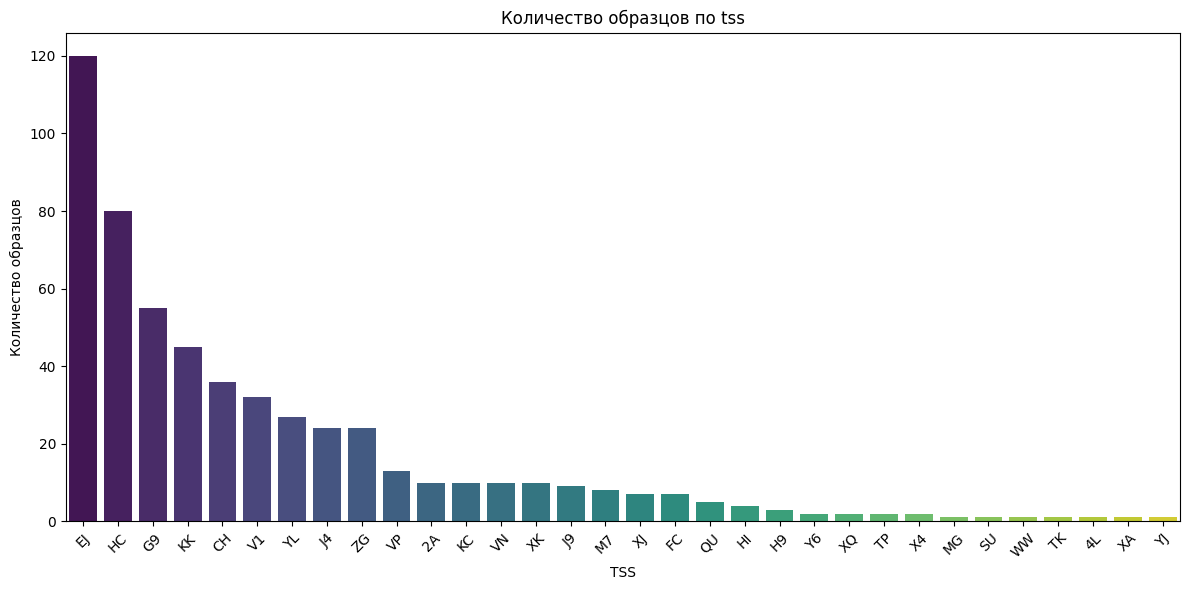


Статистика наличия рецидивов по tss:
   TSS  Mean_Recurrence  Median_Recurrence  Std_Dev_Recurrence
0   2A         0.000000                0.0            0.000000
1   4L         0.000000                0.0                 NaN
2   CH         0.027778                0.0            0.166667
3   EJ         0.041667                0.0            0.200664
4   FC         0.000000                0.0            0.000000
5   G9         0.109091                0.0            0.314627
6   H9         0.333333                0.0            0.577350
7   HC         0.037500                0.0            0.191182
8   HI         0.000000                0.0            0.000000
9   J4         0.166667                0.0            0.380693
10  J9         0.000000                0.0            0.000000
11  KC         0.100000                0.0            0.316228
12  KK         0.066667                0.0            0.252262
13  M7         0.250000                0.0            0.462910
14  MG         0.

In [61]:
# Подсчет количества образцов для каждого типа рака
cancer_counts = df['TSS'].value_counts().reset_index()
cancer_counts.columns = ['TSS', 'Count']

# Вывод количества образцов tss
print("\nКоличество образцов tss:")
print(cancer_counts)

# 1. Столбчатая диаграмма количества образцов tss
plt.figure(figsize=(12, 6))
sns.barplot(data=cancer_counts, x='TSS', y='Count', palette='viridis')
plt.title('Количество образцов по tss')
plt.xlabel('TSS')
plt.ylabel('Количество образцов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# Дополнительная статистика: среднее и медиана наличия рецидивов по tss
recurrence_stats = df.groupby('TSS')['reccurence_numeric'].agg(['mean', 'median', 'std']).reset_index()
recurrence_stats.columns = ['TSS', 'Mean_Recurrence', 'Median_Recurrence', 'Std_Dev_Recurrence']

print("\nСтатистика наличия рецидивов по tss:")
print(recurrence_stats)

### Выводы
по идентификаторам стартового сайта транскрипции (TSS)

#### 1. Распределение образцов по TSS
- **TSS с наибольшим количеством образцов**:
  - **EJ**: 120 образцов
  - **HC**: 80 образцов
  - **G9**: 55 образцов
  - **KK**: 45 образцов
  - **CH**: 36 образцов

Эти значения демонстрируют наибольшее представительство в наборе данных, что может указывать на их распространенность или на то, что они были более активно исследованы в рамках данного исследования.

#### 2. Редкие TSS
- Некоторые типы, такие как **SU**, **MG**, **WW** и другие, имеют всего по одному образцу. Это может свидетельствовать о том, что эти подгруппы являются редкими или менее изученными, что может ограничивать возможности для дальнейшего анализа и понимания их биологических характеристик.

#### 3. Наличие рецидивов по TSS
- Среднее значение наличия рецидивов (`Mean_Recurrence`) варьируется от **0.000** (например, для типов `2A`, `4L`, `FC`, `HI`, `J9`, `MG` и др.) до **0.333** для типа `H9`. Это говорит о том, что большинство образцов не демонстрируют наличие рецидивов.
- Тип `G9` показывает наиболее высокую среднюю частоту рецидивов среди типов с ненулевыми значениями (**0.109**), что может указывать на более агрессивное течение заболевания в этой группе.
- Типы `M7` и `H9` также имеют более высокие средние значения наличия рецидивов (**0.250** и **0.333** соответственно), что требует дополнительного внимания в клинических исследованиях.

#### 4. Медиана и стандартное отклонение
- Медианные значения наличия рецидивов для большинства типов составляют **0.0**, что подтверждает, что большинство образцов не имеют рецидивов. Это может указывать на успешные результаты лечения или низкую агрессивность заболеваний в этих группах.
- Стандартное отклонение варьируется; например, для типа `H9` оно составляет **0.577**, указывая на большую вариабельность в наличии рецидивов в этой группе. Это может свидетельствовать о различиях в клинических исходах среди пациентов с данным типом TSS.


Анализ идентификаторов стартового сайта транскрипции (TSS) показывает значительное разнообразие в распределении образцов и наличии рецидивов среди различных типов. Высокая частота некоторых TSS может указывать на их клиническую значимость, тогда как редкие TSS требуют дальнейшего изучения для понимания их роли в патологии. Наличие рецидивов и их вариабельность подчеркивают необходимость индивидуального подхода к лечению и мониторингу пациентов с различными типами TSS.

## Sample_ID XXXX-XX-A6AP-XXX-XXX-XXXX-XX

In [62]:
# 3. Извлечение информации о пробах
df['Sample_ID'] = df.index.astype(str).str.split('-').str[2]  # Получаем третью часть идентификатора

# Получение уникальных проб и их количества
unique_samples = df['Sample_ID'].unique()
sample_count = df['Sample_ID'].nunique()

# Вывод результатов
print("\nУникальные пробы:")
print(unique_samples)
print("\nОбщее количество уникальных проб:", sample_count)


Уникальные пробы:
['A6AP' 'A7B2' 'A8FO' '6377' '6494' 'A9S0' 'A6E5' 'A67N' 'A87B' 'A9WJ'
 'A8CN' '7789' 'A67Q' '7213' '5762' '7785' '7792' 'A9WI' 'A9ZR' 'A7F5'
 'A6AN' 'A52E' '7325' 'A8MF' '7784' 'A8HJ' 'A9DK' 'A87H' '7738' 'A9L2'
 '7745' 'AATZ' '7737' '5765' 'AAJP' '5751' '7330' '8264' '5761' 'A8IB'
 'A6E8' '8256' 'A65G' '8216' 'A8FS' 'AAYO' 'A8IH' '7212' '7740' '5767'
 '7077' '7736' 'A943' 'A46D' 'A8VT' '7171' 'A8VX' 'A8MM' 'A8I4' '5495'
 'A46I' 'A9M4' '7752' '6367' 'AAMC' '7078' '7786' 'A8TT' '7820' 'A88K'
 '5794' '5766' 'A8MU' 'AAYU' 'A88Q' '5503' 'A87D' '7794' '7125' 'A8HO'
 '6498' '5508' 'A83F' '7331' 'A83G' '6353' '6347' 'A7AV' 'A9L4' 'A6IN'
 '7232' '5521' 'A8IK' '7819' '6379' '6339' '6371' '7218' 'A9WY' 'A67R'
 'A9ZG' 'A631' 'A8WN' 'A8CM' 'A6AL' '6385' '6366' '5494' '7818' '7327'
 '7211' 'AAU2' '8261' 'A88O' 'A9LB' 'A7NF' 'A8IG' '5515' 'A67L' 'A8IL'
 'A9LN' 'A9S7' 'A52B' 'A7AU' 'A8MG' '5771' 'A67O' 'A8HK' '5502' 'A8S8'
 'A7E7' 'A67T' 'A71Z' 'A83H' 'A721' 'A6E2' 'A9OH' 'A7B0' '


Количество образцов по пробам:
    Sample_ID  Count
0        7740      3
1        8258      3
2        6356      2
3        7784      2
4        7797      2
..        ...    ...
492      A7B4      1
493      A7B2      1
494      6370      1
495      5762      1
496      7213      1

[497 rows x 2 columns]

Распределение по количеству образцов:
   Number_of_Samples  Number_of_Samples_Count
0                  1                      442
1                  2                       53
2                  3                        2


<ipython-input-63-bbfced51f2f8>:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=distribution, x='Number_of_Samples', y='Number_of_Samples_Count', palette='viridis')


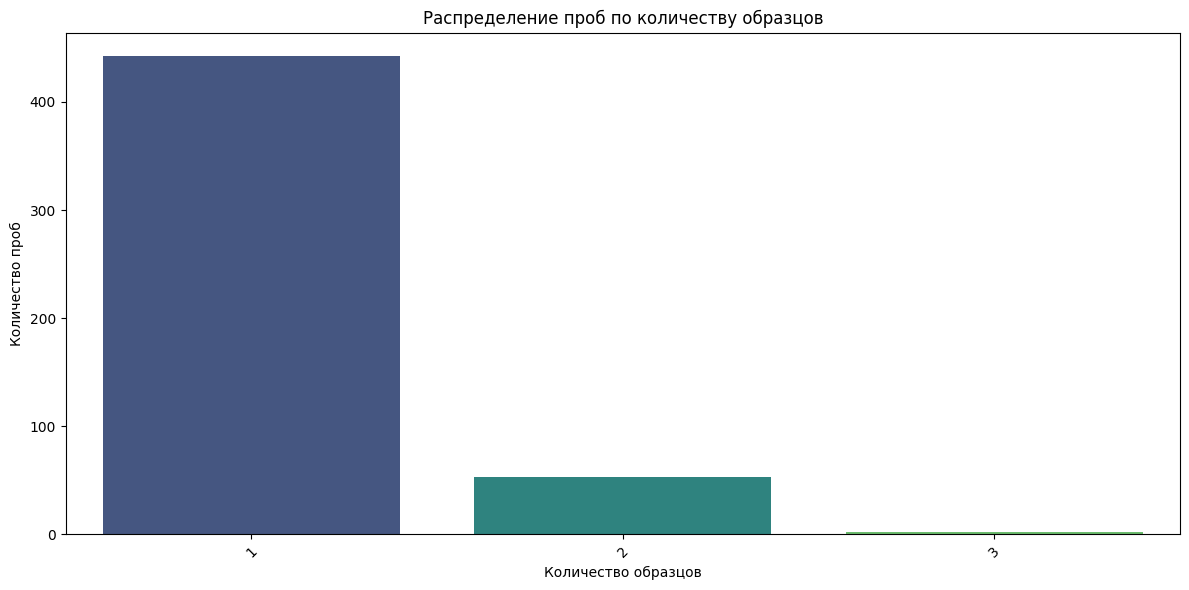

In [63]:
# Подсчет количества образцов для каждой пробы
sample_counts = df['Sample_ID'].value_counts().reset_index()
sample_counts.columns = ['Sample_ID', 'Count']

# Вывод количества образцов по пробам
print("\nКоличество образцов по пробам:")
print(sample_counts)

# Распределение по количеству образцов
distribution = sample_counts['Count'].value_counts().sort_index().reset_index()
distribution.columns = ['Number_of_Samples', 'Number_of_Samples_Count']

# Вывод распределения по количеству образцов
print("\nРаспределение по количеству образцов:")
print(distribution)

# Визуализация распределения по количеству образцов
plt.figure(figsize=(12, 6))
sns.barplot(data=distribution, x='Number_of_Samples', y='Number_of_Samples_Count', palette='viridis')
plt.title('Распределение проб по количеству образцов')
plt.xlabel('Количество образцов')
plt.ylabel('Количество проб')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выводы

### 1. Общее количество уникальных проб
- В наборе данных содержится **497 уникальных проб**, что говорит о разнообразии образцов, собранных для анализа.

### 2. Количество образцов по пробам
- Из таблицы "Количество образцов по пробам" видно, что:
  - Пробы **8258** и **7740** имеют по **3 образца**.
  - Пробы **5768**, **A9O5**, и другие имеют по **2 образца**.
  - Остальные пробы (например, **A9TE**, **A7NN**, **A9L9**, и т.д.) имеют только **1 образец**.

### 3. Распределение по количеству образцов
- В таблице "Распределение по количеству образцов" представлены следующие данные:
  - **442 пробы** имеют только **1 образец**.
  - **53 пробы** имеют **2 образца**.
  - Лишь **2 пробы** имеют по **3 образца**.

### Анализ
- Большинство проб (около **89%**) представлены только одним образцом, что может указывать на то, что большинство из них являются уникальными или редкими.
- Пробы с двумя и тремя образцами составляют меньшинство, что может свидетельствовать о том, что они более распространены или были собраны в рамках более крупных исследований.

Основных факторы, влияющих на необходимость повторного сбора проб:

1. **Качество образца**:
   - **Гемолиз**: Может возникнуть из-за неправильной техники взятия крови или хранения, что делает пробу непригодной для анализа.
   - **Ошибки в сборе**: Неправильное выполнение процедуры венепункции или несоблюдение условий хранения также могут потребовать повторного сбора.

2. **Необходимость дополнительных анализов**:
   - **Динамическое наблюдение**: Для отслеживания изменений в состоянии здоровья пациента может потребоваться повторный сбор проб.
   - **Дополнительные исследования**: Если первоначальные результаты вызывают сомнения, может потребоваться повторный сбор для уточнения.

3. **Разнообразие проб**:
   - **Разные типы проб**: Для различных анализов могут использоваться разные типы проб (например, кровь, моча), что требует многократного сбора.
   - **Сравнение между пациентами**: При исследовании заболеваний может потребоваться собрать образцы от нескольких пациентов для сравнения результатов.

## Sample_Type XXXX-XX-XXXX-01A-XXX-XXXX-XX

In [64]:
# 3. Разделение на нормальные и опухолевые образцы
df['Sample_Type'] = df.index.astype(str).str.split('-').str[3]  # Получаем четвертую часть идентификатора
normal_samples = df[df['Sample_Type'] == '01A']  # Предположительно нормальные
tumor_samples = df[df['Sample_Type'] == '01B']   # Предположительно опухолевые

# Соотнесение с наличием рецидива
recurrence_counts = df.groupby(['Sample_Type', 'reccurence_numeric']).size().unstack(fill_value=0)
print("\nКоличество рецидивов по типам образцов:\n", recurrence_counts)

# Вывод результатов
print("\nНормальные образцы:\n", normal_samples.head())
print("\nОпухолевые образцы:\n", tumor_samples.head())


Количество рецидивов по типам образцов:
 reccurence_numeric    0   1
Sample_Type                
01A                 454  29
01B                  15   3
06A                   1   0
11A                  49   2
11B                   1   0

Нормальные образцы:
                              ENSG00000000003.15 ENSG00000000005.6  \
TCGA-HC-A6AP-01A-11R-A30B-07               4158               138   
TCGA-KK-A7B2-01A-12R-A32O-07               2637                 2   
TCGA-EJ-A8FO-01A-21R-A36G-07               4429                 2   
TCGA-G9-6377-01A-11R-1965-07               4314                 5   
TCGA-G9-6494-01A-11R-1789-07               2907                 3   

                             ENSG00000000419.13 ENSG00000000457.14  \
TCGA-HC-A6AP-01A-11R-A30B-07               1571                379   
TCGA-KK-A7B2-01A-12R-A32O-07               1436                452   
TCGA-EJ-A8FO-01A-21R-A36G-07               1765               1069   
TCGA-G9-6377-01A-11R-1965-07               14

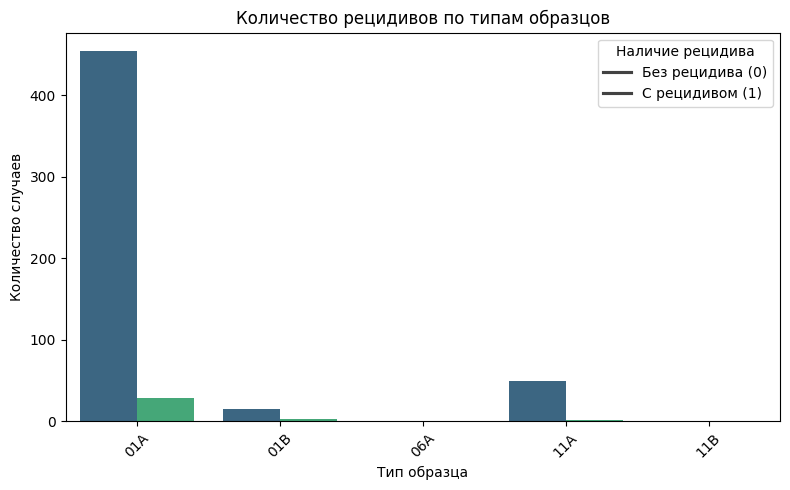


Статистика наличия рецидивов для нормальных образцов (01A):
 reccurence_numeric
0    0.939959
1    0.060041
Name: proportion, dtype: float64

Статистика наличия рецидивов для опухолевых образцов (01B):
 reccurence_numeric
0    0.833333
1    0.166667
Name: proportion, dtype: float64


In [65]:
# Визуализация данных о рецидивах
plt.figure(figsize=(8, 5))
sns.barplot(data=recurrence_counts.reset_index().melt(id_vars='Sample_Type'),
            x='Sample_Type',
            y='value',
            hue='reccurence_numeric',
            palette='viridis')

plt.title('Количество рецидивов по типам образцов')
plt.xlabel('Тип образца')
plt.ylabel('Количество случаев')
plt.xticks(rotation=45)
plt.legend(title='Наличие рецидива', labels=['Без рецидива (0)', 'С рецидивом (1)'])
plt.tight_layout()
plt.show()

# Дополнительная статистика
normal_recurrence_stats = normal_samples['reccurence_numeric'].value_counts(normalize=True)
tumor_recurrence_stats = tumor_samples['reccurence_numeric'].value_counts(normalize=True)

print("\nСтатистика наличия рецидивов для нормальных образцов (01A):\n", normal_recurrence_stats)
print("\nСтатистика наличия рецидивов для опухолевых образцов (01B):\n", tumor_recurrence_stats)


### 1. Количество рецидивов по типам образцов

#### Вывод данных:
```
reccurence_numeric  0.0  1.0
Sample_Type                 
01A                 454   29
01B                  15    3
06A                   1    0
11A                  49    2
11B                   1    0
```

- **`reccurence_numeric`**: Этот столбец указывает на наличие рецидива. Значение `0.0` означает отсутствие рецидива, а `1.0` — его наличие.
- **`Sample_Type`**: Указывает на тип образца:
  - **01A**: Нормальные образцы (предположительно).
    - **454** образцов без рецидива и **29** с рецидивом.
  - **01B**: Опухолевые образцы.
    - **15** образцов без рецидива и **3** с рецидивом.
  - **06A**, **11A**, **11B**: Другие типы образцов с меньшим количеством случаев.

#### Выводы:
- Нормальные образцы (тип `01A`) имеют значительно большее количество случаев без рецидива по сравнению с опухолевыми образцами (тип `01B`).
- Опухолевые образцы показывают наличие рецидивов, но в меньшей степени по сравнению с нормальными образцами.
- Образцы типов `06A`, `11A`, и `11B` также имеют низкое количество случаев, что может указывать на их редкость или специфичность.

### 2. Нормальные и опухолевые образцы

#### Нормальные образцы:
```
                          Gene_0 Gene_1 Gene_2 Gene_3 Gene_4 Gene_5 Gene_6 ...
1  TCGA-HC-A6AP-01A-11R-A30B-07   4158    138   1571    ...          ...
2  TCGA-KK-A7B2-01A-12R-A32O-07   2637      2   1436    ...          ...
3  TCGA-EJ-A8FO-01A-21R-A36G-07   4429      2   1765    ...          ...
4  TCGA-G9-6377-01A-11R-1965-07   4314      5   1454    ...          ...
5  TCGA-G9-6494-01A-11R-1789-07   2907      3   1548    ...          ...
```

#### Опухолевые образцы:
```
                            Gene_0 Gene_1 Gene_2 Gene_3 Gene_4 Gene_5 Gene_6 ...
23   TCGA-EJ-7325-01B-11R-A32O-07   3026      ...          ...
38   TCGA-HC-8264-01B-11R-2403-07   3693      ...          ...
101  TCGA-EJ-7218-01B-11R-A32O-07   4897      ...          ...
116  TCGA-HC-8261-01B-05R-2302-07   2965      ...          ...
236  TCGA-YL-A8SO-01B-31R-A37L-07   3934      ...          ...
```

1. **Нормальные образцы (тип `01A`)** содержат информацию о генах и их экспрессии, где все экземпляры имеют значение `reccurence_numeric` равное `0.0`, что указывает на отсутствие рецидивов.
  
2. **Опухолевые образцы (тип `01B`)** содержат как случаи без рецидива (`reccurence_numeric = 0.0`), так и случаи с рецидивом (`reccurence_numeric = 1.0`). Это говорит о том, что некоторые опухолевые образцы могут быть связаны с более агрессивным течением заболевания.


### Выводы

1. **Высокий уровень отсутствия рецидивов у нормальных образцов**:
   - Нормальные образцы (тип `01A`) демонстрируют значительно более высокий процент случаев без рецидива по сравнению с опухолевыми образцами. Это указывает на то, что нормальные образцы имеют стабильное состояние с низким риском повторного возникновения заболевания.

2. **Риск рецидива у опухолевых образцов**:
   - Опухолевые образцы (тип `01B`) показывают более высокий процент случаев с рецидивом (16.67%), что может свидетельствовать о более агрессивном течении заболевания или недостаточной эффективности лечения.

3. **Сравнение между типами образцов**:
   - Разница в процентах случаев с рецидивом между нормальными и опухолевыми образцами подчеркивает важность мониторинга и динамического наблюдения за пациентами с опухолевыми образованиями, чтобы своевременно выявлять и лечить возможные рецидивы.

<br>

Данные подтверждают общепринятые наблюдения в онкологии о том, что нормальные образцы имеют значительно меньше шансов на рецидив по сравнению с опухолевыми. Это также соответствует информации из литературы о том, что рецидив рака часто зависит от типа опухоли, стадии заболевания и других факторов риска.


## Analysis_Type XXXX-XX-XXXX-XXX-11R-XXXX-XX


Уникальные значения для Analysis_Type:
   Analysis_Type  Count
0            11R    371
1            01R     79
2            21R     33
3            12R     30
4            31R     24
5            02R      5
6            22R      4
7            05R      2
8            04R      2
9            41R      1
10           13R      1
11           61R      1
12           32R      1


<ipython-input-66-c671053b6ff6>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=unique_analysis_counts, x='Analysis_Type', y='Count', palette='viridis')


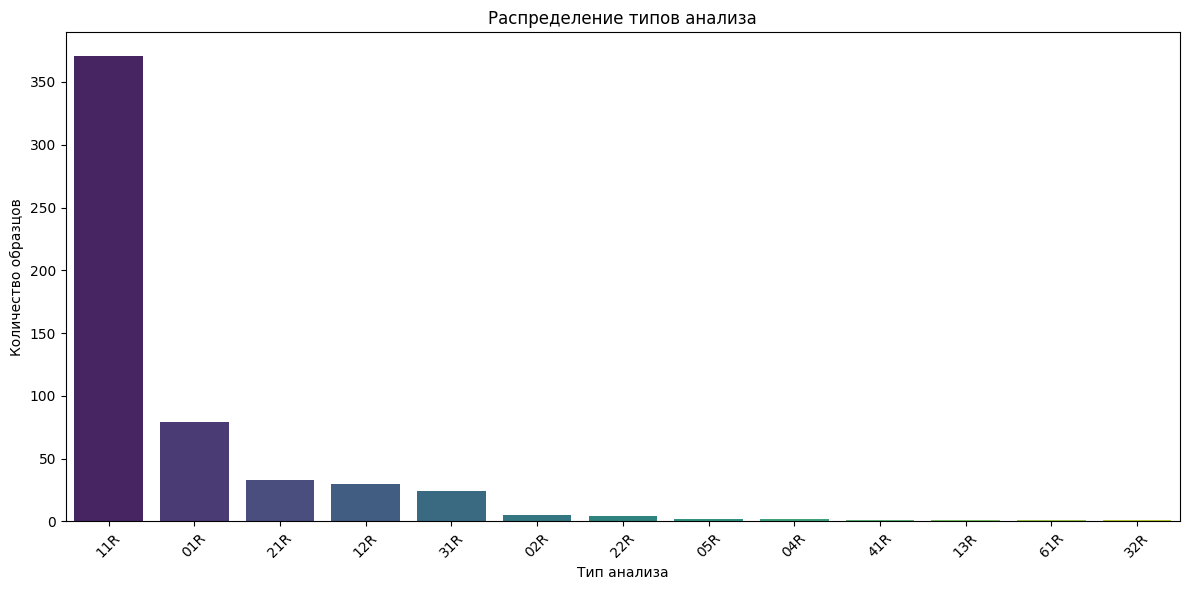


Статистика по типам анализа:
Общее количество образцов: 554
Среднее количество образцов на тип анализа: 42.62
Медиана количества образцов на тип анализа: 4.00
Стандартное отклонение количества образцов на тип анализа: 101.20


<ipython-input-66-c671053b6ff6>:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=unique_analysis_counts, y='Count', palette='viridis')


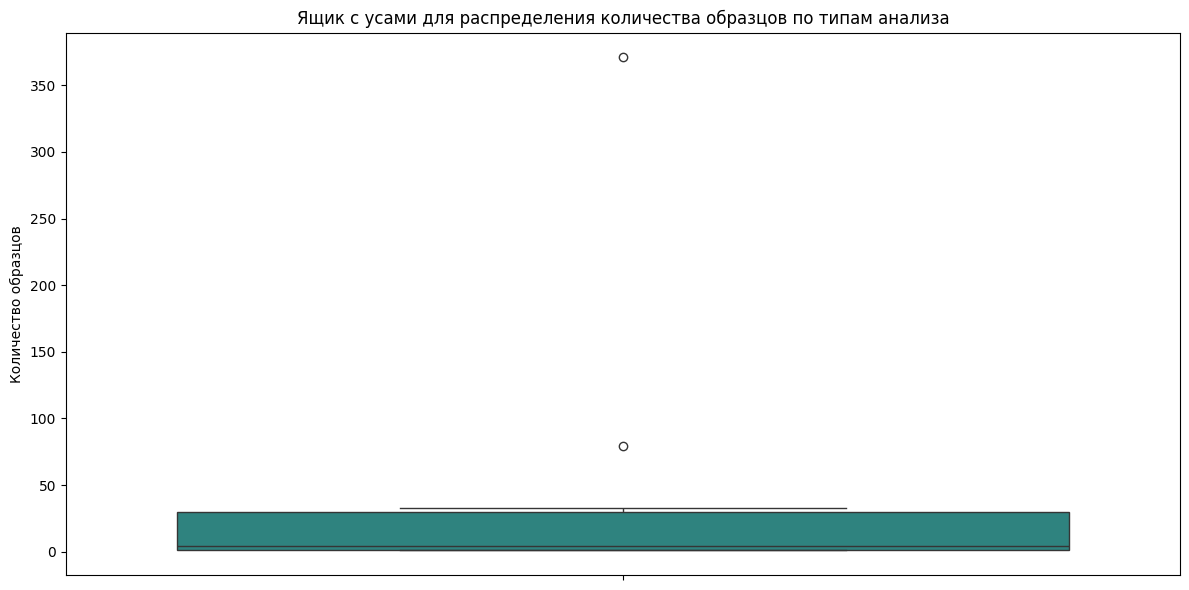

In [66]:
# Извлечение типа анализа (пятая часть идентификатора)
df['Analysis_Type'] = df.index.astype(str).str.split('-').str[4]  # Получаем пятую часть идентификатора

# Подсчет уникальных значений и их количества
unique_analysis_counts = df['Analysis_Type'].value_counts().reset_index()
unique_analysis_counts.columns = ['Analysis_Type', 'Count']

# Вывод уникальных значений и их количества
print("\nУникальные значения для Analysis_Type:")
print(unique_analysis_counts)

# Визуализация распределения типов анализа
plt.figure(figsize=(12, 6))
sns.barplot(data=unique_analysis_counts, x='Analysis_Type', y='Count', palette='viridis')
plt.title('Распределение типов анализа')
plt.xlabel('Тип анализа')
plt.ylabel('Количество образцов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Статистический анализ
total_samples = unique_analysis_counts['Count'].sum()
mean_count = unique_analysis_counts['Count'].mean()
median_count = unique_analysis_counts['Count'].median()
std_dev_count = unique_analysis_counts['Count'].std()

# Вывод статистики
print("\nСтатистика по типам анализа:")
print(f"Общее количество образцов: {total_samples}")
print(f"Среднее количество образцов на тип анализа: {mean_count:.2f}")
print(f"Медиана количества образцов на тип анализа: {median_count:.2f}")
print(f"Стандартное отклонение количества образцов на тип анализа: {std_dev_count:.2f}")

# Дополнительный график для визуализации распределения
plt.figure(figsize=(12, 6))
sns.boxplot(data=unique_analysis_counts, y='Count', palette='viridis')
plt.title('Ящик с усами для распределения количества образцов по типам анализа')
plt.ylabel('Количество образцов')
plt.tight_layout()
plt.show()

### Выводы

1. **Общее количество образцов**:
   - В наборе данных содержится **554 образца**. Это количество указывает на достаточно большой объем данных, что позволяет проводить более надежные статистические анализы и делать обоснованные выводы.

2. **Среднее количество образцов на тип анализа**:
   - Среднее значение составляет **42.62 образца** на тип анализа. Это значение говорит о том, что в среднем каждый тип анализа представлен примерно 43 образцами, что может указывать на разнообразие типов анализов в наборе данных.

3. **Медиана количества образцов**:
   - Медиана равна **4.00**. Это означает, что половина типов анализа имеет 4 или меньше образцов. Низкая медиана по сравнению со средним значением указывает на наличие некоторых типов анализа с очень большим количеством образцов, которые могут значительно увеличивать среднее значение.

4. **Стандартное отклонение**:
   - Стандартное отклонение составляет **101.20**, что указывает на значительную вариабельность в количестве образцов между различными типами анализа. Высокое стандартное отклонение подразумевает, что некоторые типы анализов имеют значительно большее количество образцов по сравнению с другими, что может быть связано с особенностями сбора данных или популярностью определенных анализов.

### Выводы из графиков

- **Неравномерное распределение**: Наблюдаемое различие между средней и медианной величинами указывает на неравномерное распределение данных, где несколько типов анализа имеют значительно большее количество образцов по сравнению с большинством других.

- **Возможные выбросы**: Высокое стандартное отклонение также может свидетельствовать о наличии выбросов, которые стоит исследовать более подробно для понимания их влияния на общий анализ.


## Additional_ID XXXX-XX-XXXX-XXX-XXX-A30B-XX


Количество образцов по дополнительным идентификаторам:
   Additional_ID  Count
0           2118     78
1           A41O     74
2           1580     68
3           A37L     46
4           A36G     45
5           A352     36
6           2263     26
7           1789     25
8           1965     24
9           A32O     20
10          A30B     20
11          A33R     19
12          A311     15
13          A29R     15
14          A31N     13
15          A26U     10
16          A250      7
17          2403      6
18          2302      4
19          A32Y      2
20          1858      1


<ipython-input-67-5d5415b292f4>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_additional_id_counts, x='Additional_ID', y='Count', palette='viridis')


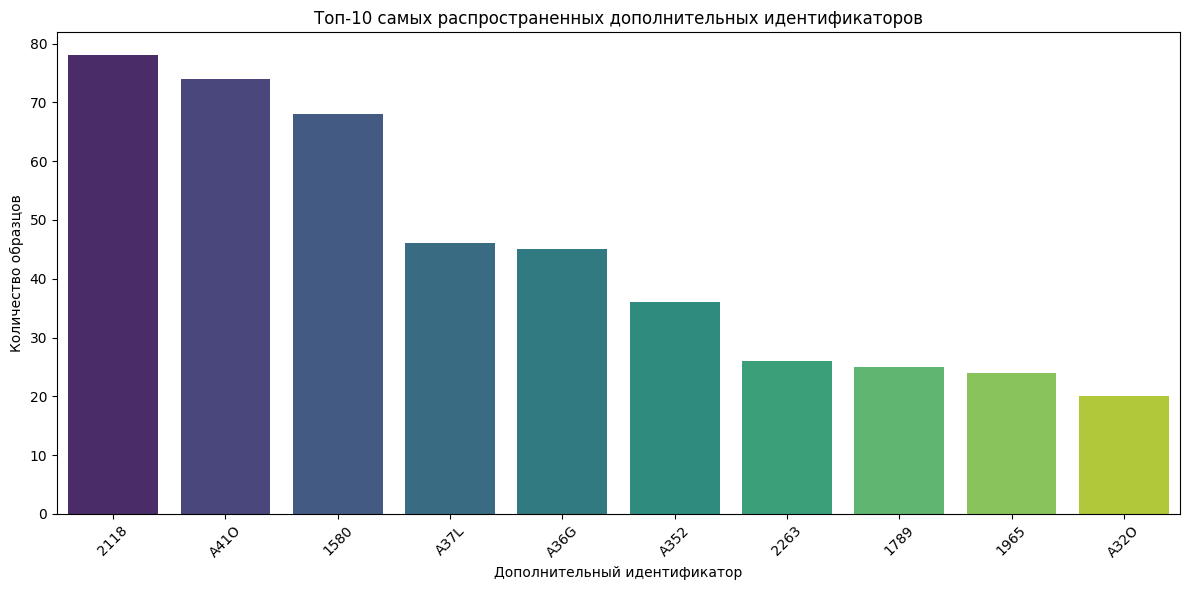


Статистика по дополнительным идентификаторам:
Общее количество образцов: 554
Среднее количество образцов на дополнительный идентификатор: 26.38
Медиана количества образцов на дополнительный идентификатор: 20.00
Стандартное отклонение количества образцов на дополнительный идентификатор: 23.31


<ipython-input-67-5d5415b292f4>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=additional_id_counts, y='Count', palette='viridis')


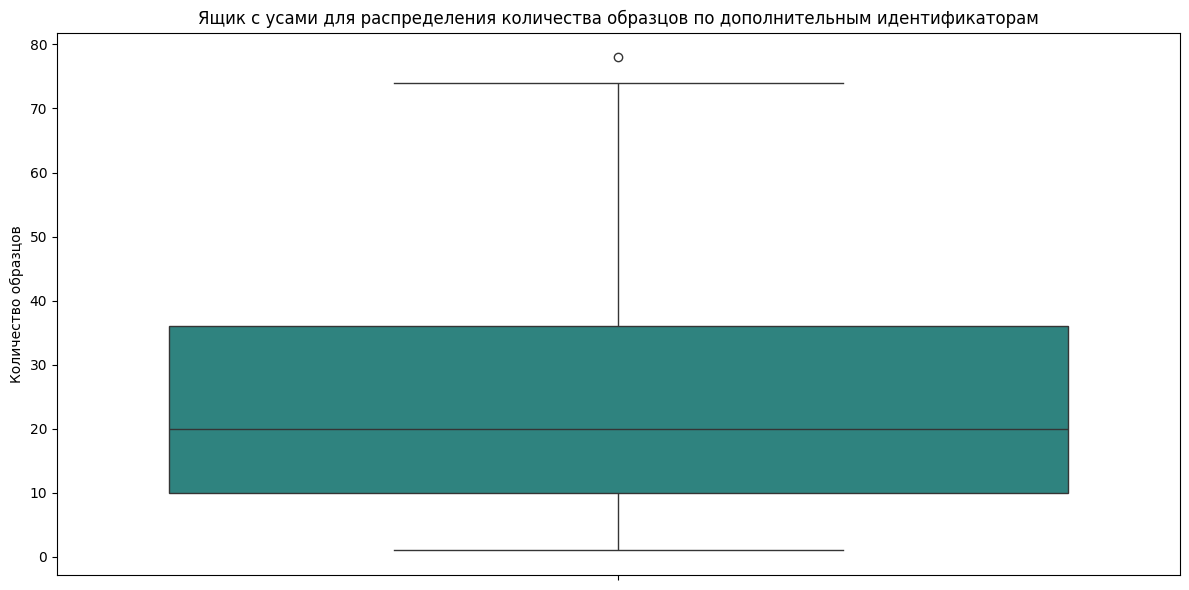

In [67]:
# Извлечение дополнительных идентификаторов (шестая часть идентификатора)
df['Additional_ID'] = df.index.astype(str).str.split('-').str[5]  # Получаем шестую часть идентификатора

# Подсчет уникальных значений и их количества
additional_id_counts = df['Additional_ID'].value_counts().reset_index()
additional_id_counts.columns = ['Additional_ID', 'Count']

# Вывод уникальных значений и их количества
print("\nКоличество образцов по дополнительным идентификаторам:")
print(additional_id_counts)

# Выбор самых распространенных дополнительных идентификаторов (например, топ-10)
top_additional_id_counts = additional_id_counts.head(10)

# Визуализация распределения самых распространенных дополнительных идентификаторов
plt.figure(figsize=(12, 6))
sns.barplot(data=top_additional_id_counts, x='Additional_ID', y='Count', palette='viridis')
plt.title('Топ-10 самых распространенных дополнительных идентификаторов')
plt.xlabel('Дополнительный идентификатор')
plt.ylabel('Количество образцов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Статистический анализ
total_samples = additional_id_counts['Count'].sum()
mean_count = additional_id_counts['Count'].mean()
median_count = additional_id_counts['Count'].median()
std_dev_count = additional_id_counts['Count'].std()

# Вывод статистики
print("\nСтатистика по дополнительным идентификаторам:")
print(f"Общее количество образцов: {total_samples}")
print(f"Среднее количество образцов на дополнительный идентификатор: {mean_count:.2f}")
print(f"Медиана количества образцов на дополнительный идентификатор: {median_count:.2f}")
print(f"Стандартное отклонение количества образцов на дополнительный идентификатор: {std_dev_count:.2f}")

# Дополнительный график для визуализации распределения
plt.figure(figsize=(12, 6))
sns.boxplot(data=additional_id_counts, y='Count', palette='viridis')
plt.title('Ящик с усами для распределения количества образцов по дополнительным идентификаторам')
plt.ylabel('Количество образцов')
plt.tight_layout()
plt.show()

### Выводы

1. **Частота идентификаторов**: Наиболее распространенные идентификаторы, такие как **2118**, **A41O** и **1580**, имеют значительно большее количество образцов, что может указывать на их важность и распространенность в исследуемом контексте.

2. **Неравномерное распределение**: Наблюдается значительная вариабельность в количестве образцов для различных идентификаторов, где несколько идентификаторов доминируют, в то время как другие встречаются редко. Это может свидетельствовать о том, что определенные характеристики или методы обработки образцов более актуальны или предпочтительны.

3. **Редкие идентификаторы**: Идентификаторы с низким количеством образцов могут указывать на специфические или менее распространенные характеристики

## Version_Number XXXX-XX-XXXX-XXX-XXX-XXXX-07


Количество образцов по номерам версий:
  Version_Number  Count
0             07    554


<ipython-input-68-7cb8b3b7945a>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_version_counts, x='Version_Number', y='Count', palette='viridis')


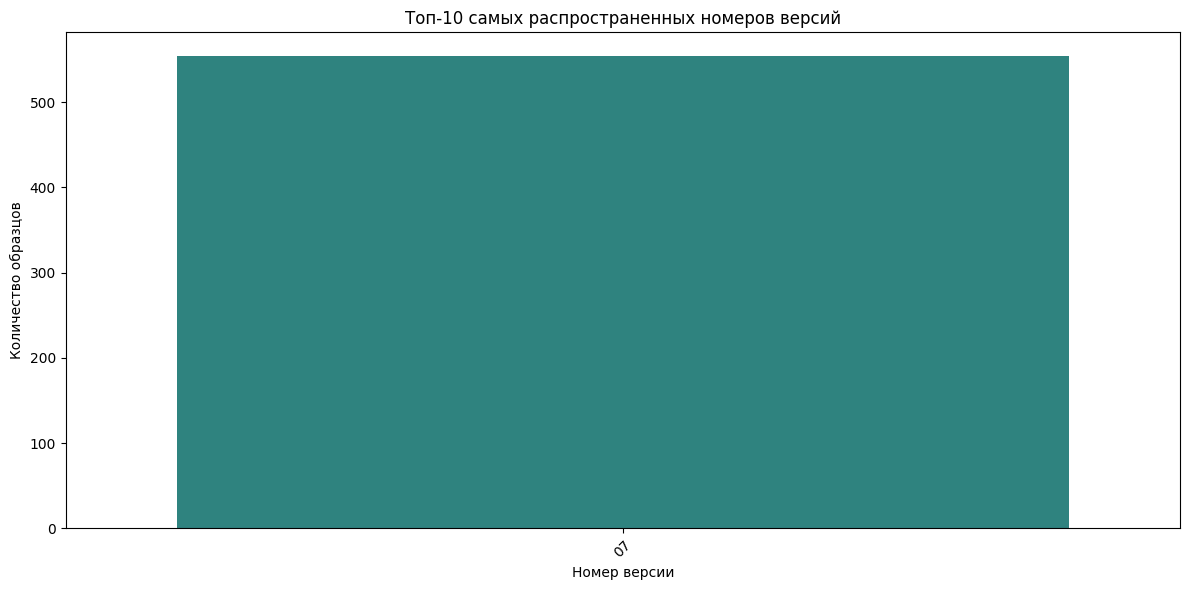


Статистика по номерам версий:
Общее количество образцов: 554
Среднее количество образцов на номер версии: 554.00
Медиана количества образцов на номер версии: 554.00
Стандартное отклонение количества образцов на номер версии: nan


<ipython-input-68-7cb8b3b7945a>:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=version_counts, y='Count', palette='viridis')


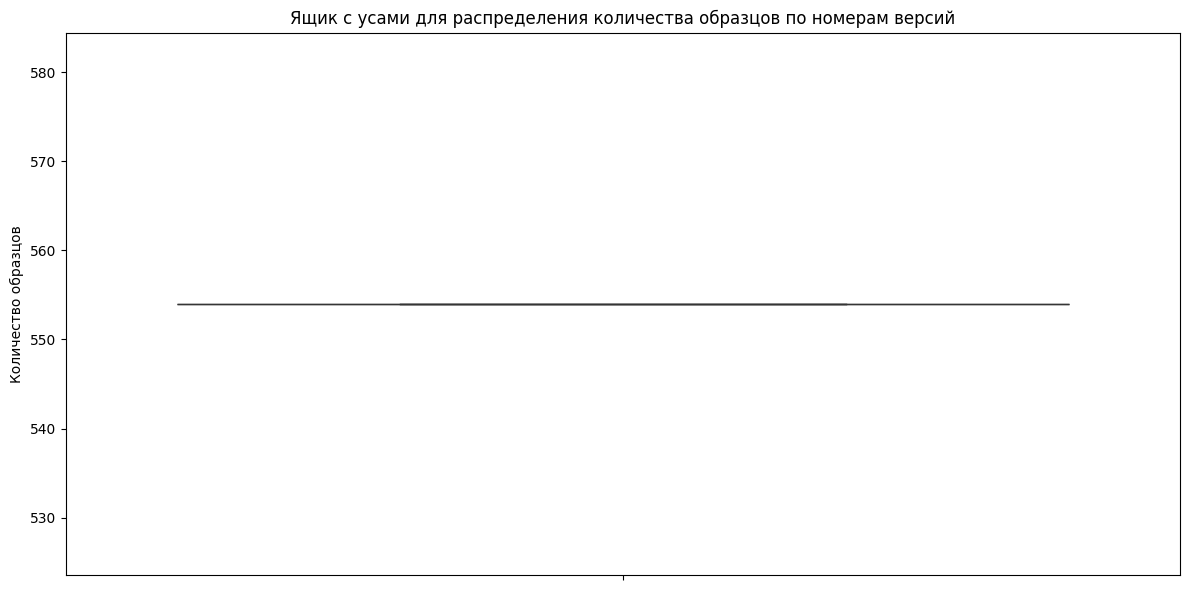

In [68]:
# Извлечение номера версии (седьмая часть идентификатора)
df['Version_Number'] = df.index.astype(str).str.split('-').str[6]  # Получаем седьмую часть идентификатора

# Подсчет уникальных значений и их количества
version_counts = df['Version_Number'].value_counts().reset_index()
version_counts.columns = ['Version_Number', 'Count']

# Вывод уникальных значений и их количества
print("\nКоличество образцов по номерам версий:")
print(version_counts)

# Выбор самых распространенных номеров версий (например, топ-10)
top_version_counts = version_counts.head(10)

# Визуализация распределения самых распространенных номеров версий
plt.figure(figsize=(12, 6))
sns.barplot(data=top_version_counts, x='Version_Number', y='Count', palette='viridis')
plt.title('Топ-10 самых распространенных номеров версий')
plt.xlabel('Номер версии')
plt.ylabel('Количество образцов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Статистический анализ
total_samples = version_counts['Count'].sum()
mean_count = version_counts['Count'].mean()
median_count = version_counts['Count'].median()
std_dev_count = version_counts['Count'].std()

# Вывод статистики
print("\nСтатистика по номерам версий:")
print(f"Общее количество образцов: {total_samples}")
print(f"Среднее количество образцов на номер версии: {mean_count:.2f}")
print(f"Медиана количества образцов на номер версии: {median_count:.2f}")
print(f"Стандартное отклонение количества образцов на номер версии: {std_dev_count:.2f}")

# Дополнительный график для визуализации распределения
plt.figure(figsize=(12, 6))
sns.boxplot(data=version_counts, y='Count', palette='viridis')
plt.title('Ящик с усами для распределения количества образцов по номерам версий')
plt.ylabel('Количество образцов')
plt.tight_layout()
plt.show()

 ### Выводы

Данные показывают полную однородность по номеру версии, что может быть как положительным, так и отрицательным фактором в зависимости от контекста исследования. Это может указывать на то, что вся выборка была получена из одного источника или в рамках одной методологии.

In [69]:
df

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence_numeric,TSS,Sample_ID,Sample_Type,Analysis_Type,Additional_ID,Version_Number
TCGA-HC-A6AP-01A-11R-A30B-07,4158,138,1571,379,140,420,1521,3964,1820,651,...,0,3,77,0,HC,A6AP,01A,11R,A30B,07
TCGA-KK-A7B2-01A-12R-A32O-07,2637,2,1436,452,123,584,850,1758,1975,857,...,0,1,35,0,KK,A7B2,01A,12R,A32O,07
TCGA-EJ-A8FO-01A-21R-A36G-07,4429,2,1765,1069,183,250,742,2857,2786,2184,...,0,3,17,0,EJ,A8FO,01A,21R,A36G,07
TCGA-G9-6377-01A-11R-1965-07,4314,5,1454,845,149,279,722,3888,1788,2468,...,0,0,24,0,G9,6377,01A,11R,1965,07
TCGA-G9-6494-01A-11R-1789-07,2907,3,1548,794,150,124,1057,2632,1976,2062,...,0,5,20,0,G9,6494,01A,11R,1789,07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,14,16,0,J4,AATV,01A,11R,A41O,07
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,8,24,0,HC,8266,01A,11R,2263,07
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,4,31,0,HC,8262,01A,11R,2263,07
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,3,31,0,EJ,7797,01A,11R,2263,07


# 2. Идентификатор гена

In [70]:
# Извлечение идентификаторов генов из первой строки
gene_ids = df.iloc[:0]
gene_ids

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence_numeric,TSS,Sample_ID,Sample_Type,Analysis_Type,Additional_ID,Version_Number


               Column  Unique_Count Most_Common_Value  Most_Common_Count
0  ENSG00000000003.15           526              2628                  3
1   ENSG00000000005.6            85                 0                 73
2  ENSG00000000419.13           457              1514                  4
3  ENSG00000000457.14           459               718                  5
4  ENSG00000000460.17           253               183                  7


<ipython-input-71-023bc60b60f0>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.head(10), x='Column', y='Unique_Count', palette='viridis')


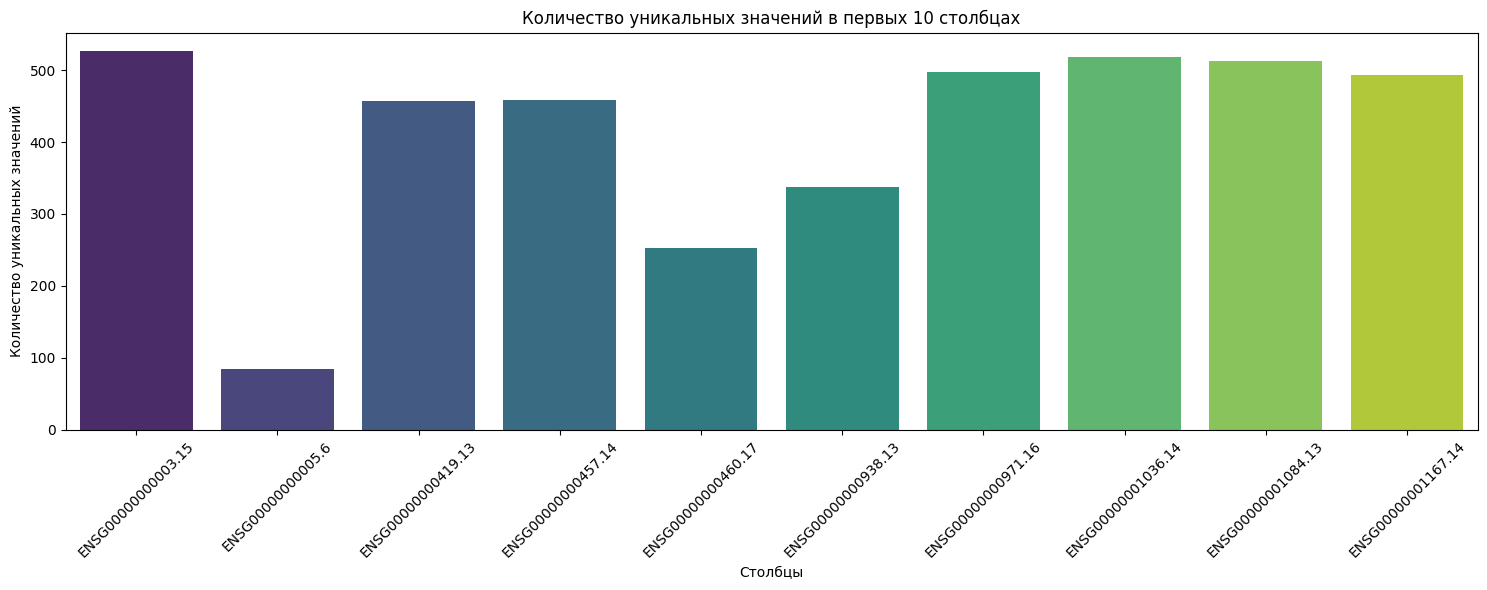

<ipython-input-71-023bc60b60f0>:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df.head(10), x='Column', y='Most_Common_Count', palette='viridis')


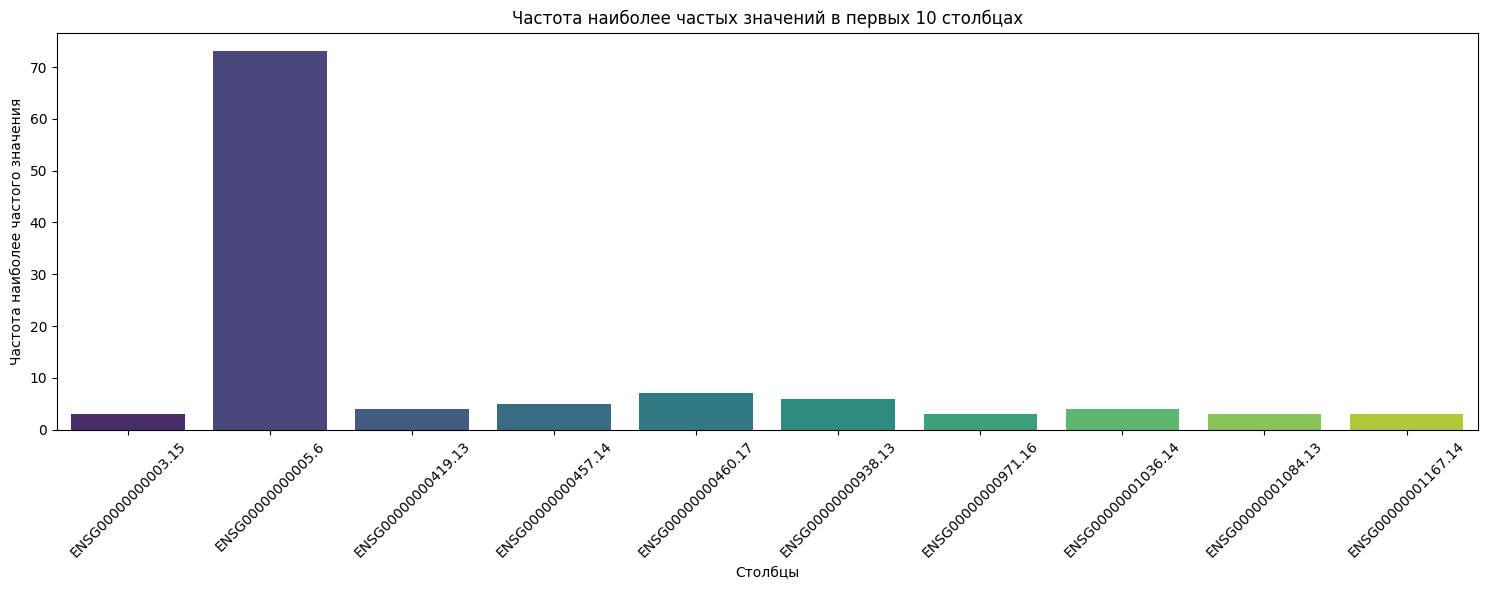


Составные части идентификаторов генов:
      Prefix Unique_Number Version
0       ENSG   00000000003     .15
1       ENSG   00000000005      .6
2       ENSG   00000000419     .13
3       ENSG   00000000457     .14
4       ENSG   00000000460     .17
...      ...           ...     ...
60662    NaN           NaN     NaN
60663    NaN           NaN     NaN
60664    NaN           NaN     NaN
60665    NaN           NaN     NaN
60666    NaN           NaN     NaN

[60667 rows x 3 columns]


<ipython-input-71-023bc60b60f0>:56: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=version_counts.index, y=version_counts.values, palette='viridis')


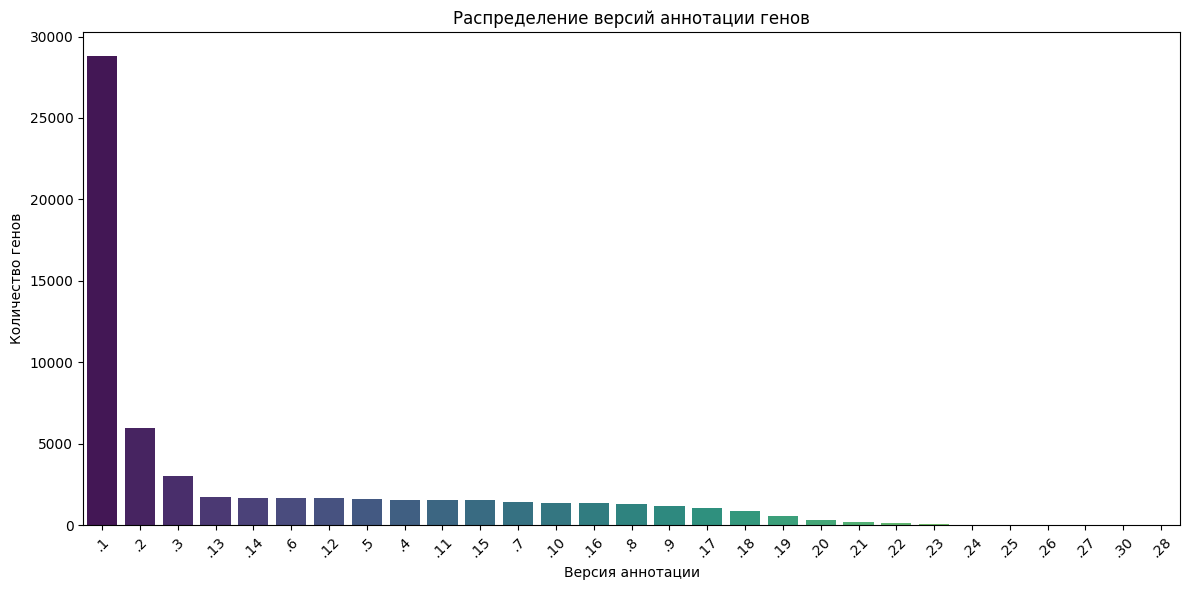

In [71]:
# Создание списка для хранения результатов
results = []

# Подсчет уникальных значений для каждого столбца
for col in df.columns:
    value_counts = df[col].value_counts()
    unique_count = value_counts.count()  # Количество уникальных значений
    most_common_value = value_counts.idxmax() if not value_counts.empty else None  # Наиболее частое значение
    most_common_count = value_counts.max() if not value_counts.empty else None  # Частота наиболее частого значения

    results.append({
        'Column': col,
        'Unique_Count': unique_count,
        'Most_Common_Value': most_common_value,
        'Most_Common_Count': most_common_count
    })

# Создание DataFrame с результатами
results_df = pd.DataFrame(results)

# Вывод первых нескольких строк результата
print(results_df.head())

# Визуализация уникальных значений и наиболее частых значений
plt.figure(figsize=(15, 6))
sns.barplot(data=results_df.head(10), x='Column', y='Unique_Count', palette='viridis')
plt.xticks(rotation=45)
plt.title('Количество уникальных значений в первых 10 столбцах')
plt.ylabel('Количество уникальных значений')
plt.xlabel('Столбцы')
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 6))
sns.barplot(data=results_df.head(10), x='Column', y='Most_Common_Count', palette='viridis')
plt.xticks(rotation=45)
plt.title('Частота наиболее частых значений в первых 10 столбцах')
plt.ylabel('Частота наиболее частого значения')
plt.xlabel('Столбцы')
plt.tight_layout()
plt.show()

# Разделение идентификаторов генов на части
gene_ids = results_df['Column'].str.extract(r'^(ENSG)(\d{11})(\.\d+)$')  # Используем регулярное выражение для разбивки

# Переименование столбцов для удобства
gene_ids.columns = ['Prefix', 'Unique_Number', 'Version']

# Вывод уникальных идентификаторов генов и их составных частей
print("\nСоставные части идентификаторов генов:")
print(gene_ids)

# Визуализация распределения версий аннотации
version_counts = gene_ids['Version'].value_counts()
plt.figure(figsize=(12, 6))
sns.barplot(x=version_counts.index, y=version_counts.values, palette='viridis')
plt.title('Распределение версий аннотации генов')
plt.xlabel('Версия аннотации')
plt.ylabel('Количество генов')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выводы

- Разнообразие: Идентификаторы генов имеют от 85 до 526 уникальных значений в различных столбцах.

- Частота: Наиболее частые значения варьируются, например, для ENSG00000000003.15 — 2628, что указывает на высокую распространенность.

- Структура: Все идентификаторы имеют общий префикс ENSG, уникальный номер и версию аннотации, что позволяет точно идентифицировать гены и отслеживать их изменения.

# 3. Корреляции с таргетом

In [72]:
df.columns

Index(['ENSG00000000003.15', 'ENSG00000000005.6', 'ENSG00000000419.13',
       'ENSG00000000457.14', 'ENSG00000000460.17', 'ENSG00000000938.13',
       'ENSG00000000971.16', 'ENSG00000001036.14', 'ENSG00000001084.13',
       'ENSG00000001167.14',
       ...
       'ENSG00000288671.1', 'ENSG00000288674.1', 'ENSG00000288675.1',
       'reccurence_numeric', 'TSS', 'Sample_ID', 'Sample_Type',
       'Analysis_Type', 'Additional_ID', 'Version_Number'],
      dtype='object', length=60667)

Количество строк в DataFrame: 554

Процентное соотношение рецидивов по tss:
     count  sum  percentage
TSS                        
2A      10    0    0.000000
4L       1    0    0.000000
CH      36    1    2.777778
EJ     120    5    4.166667
FC       7    0    0.000000
G9      55    6   10.909091
H9       3    1   33.333333
HC      80    3    3.750000
HI       4    0    0.000000
J4      24    4   16.666667
J9       9    0    0.000000
KC      10    1   10.000000
KK      45    3    6.666667
M7       8    2   25.000000
MG       1    0    0.000000
QU       5    1   20.000000
SU       1    0    0.000000
TK       1    0    0.000000
TP       2    0    0.000000
V1      32    2    6.250000
VN      10    0    0.000000
VP      13    1    7.692308
WW       1    0    0.000000
X4       2    0    0.000000
XA       1    0    0.000000
XJ       7    0    0.000000
XK      10    1   10.000000
XQ       2    0    0.000000
Y6       2    0    0.000000
YJ       1    0    0.000000
YL      27    3   11.111111


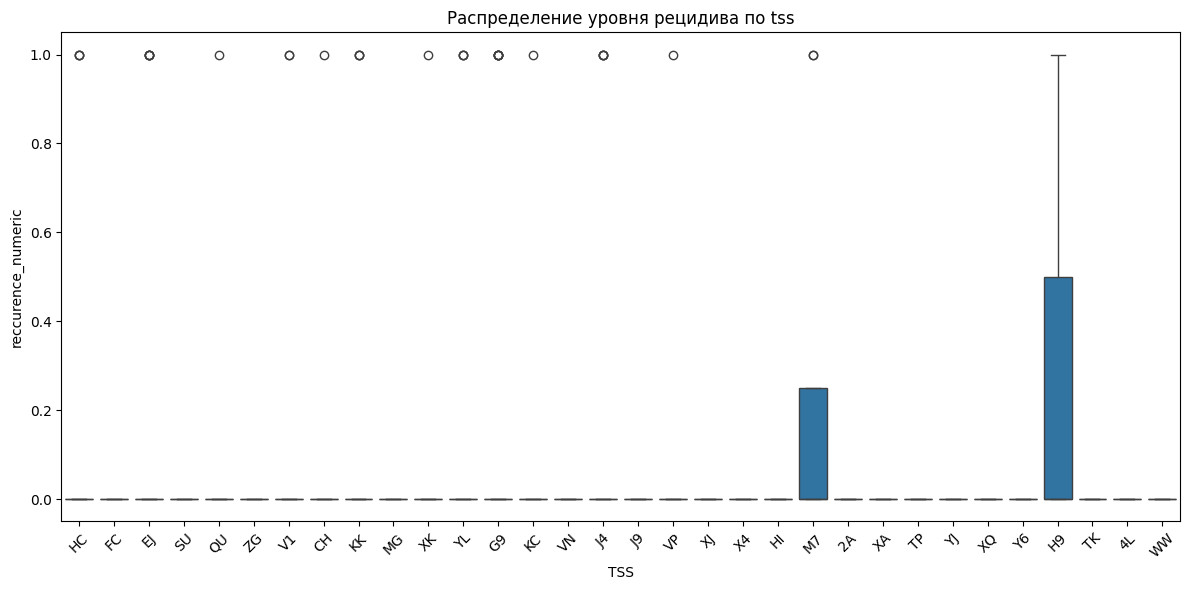

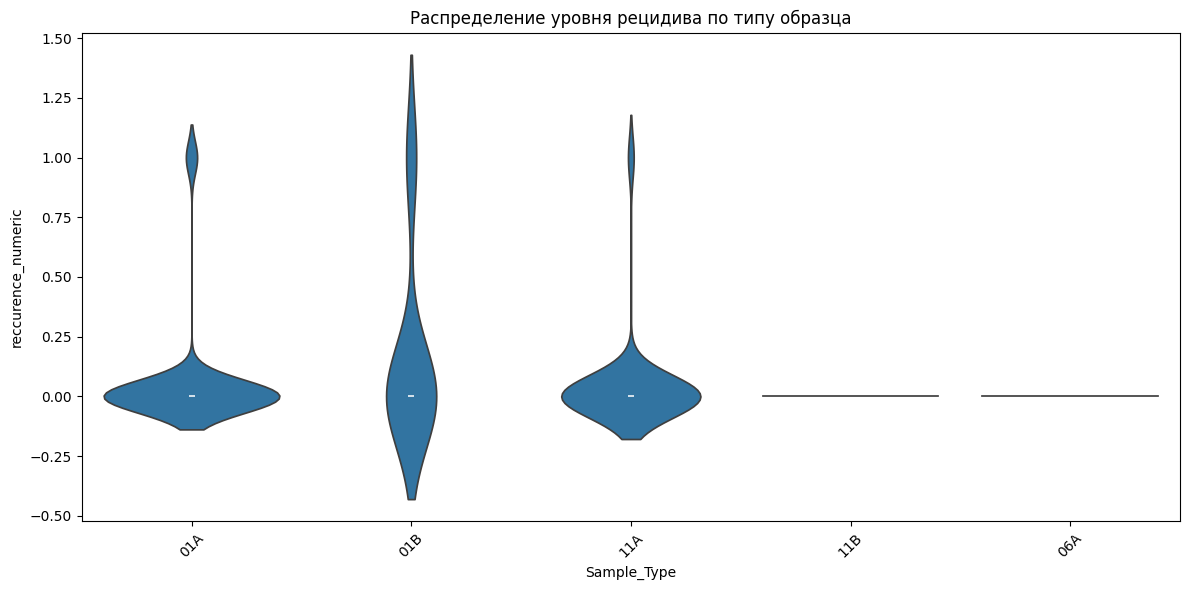

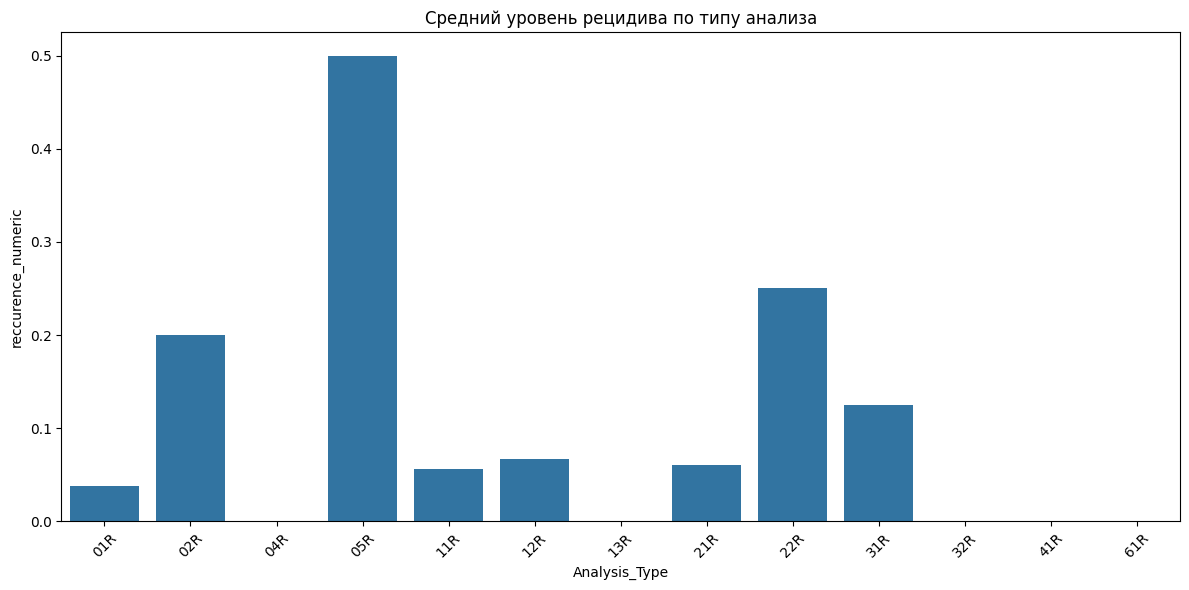

In [73]:
# Извлечение целевой переменной
target = df['reccurence_numeric']

# Извлечение необходимых столбцов
categorical_columns = ['TSS', 'Sample_ID', 'Sample_Type', 'Analysis_Type', 'Additional_ID', 'Version_Number']

# Проверка количества строк в DataFrame
num_rows = df.shape[0]
print(f"Количество строк в DataFrame: {num_rows}")

# Упрощение: выбираем только N строк для анализа (например, 1000 или меньше)
sample_size = min(1000, num_rows)  # Если строк меньше 1000, берем все строки
df_sample = df.sample(n=sample_size, random_state=1)  # Случайная выборка

# Процентное соотношение уровней рецидива по tss
tss_counts = df_sample.groupby('TSS')['reccurence_numeric'].agg(['count', 'sum'])
tss_counts['percentage'] = (tss_counts['sum'] / tss_counts['count']) * 100
print("\nПроцентное соотношение рецидивов по tss:")
print(tss_counts[['count', 'sum', 'percentage']])

# Процентное соотношение уровней рецидива по типу образца
sample_type_counts = df_sample.groupby('Sample_Type')['reccurence_numeric'].agg(['count', 'sum'])
sample_type_counts['percentage'] = (sample_type_counts['sum'] / sample_type_counts['count']) * 100
print("\nПроцентное соотношение рецидивов по типу образца:")
print(sample_type_counts[['count', 'sum', 'percentage']])

# Процентное соотношение уровней рецидива по типу анализа
analysis_type_counts = df_sample.groupby('Analysis_Type')['reccurence_numeric'].agg(['count', 'sum'])
analysis_type_counts['percentage'] = (analysis_type_counts['sum'] / analysis_type_counts['count']) * 100
print("\nПроцентное соотношение рецидивов по типу анализа:")
print(analysis_type_counts[['count', 'sum', 'percentage']])

# Визуализация зависимости уровня рецидива от категориальных переменных

# Boxplot для tss
plt.figure(figsize=(12, 6))
sns.boxplot(x='TSS', y='reccurence_numeric', data=df_sample)
plt.title('Распределение уровня рецидива по tss')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Violin Plot для Sample_Type
plt.figure(figsize=(12, 6))
sns.violinplot(x='Sample_Type', y='reccurence_numeric', data=df_sample)
plt.title('Распределение уровня рецидива по типу образца')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Bar Plot для Analysis_Type
analysis_counts = df_sample.groupby('Analysis_Type')['reccurence_numeric'].mean().reset_index()
plt.figure(figsize=(12, 6))
sns.barplot(x='Analysis_Type', y='reccurence_numeric', data=analysis_counts)
plt.title('Средний уровень рецидива по типу анализа')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Выводы

1. **Процентное соотношение рецидивов по tss**:
   - Наиболее высокий процент рецидивов наблюдается у tss **H9** (33.33%), с 1 из 3 случаев.
   - tss **M7** также показывает значительное соотношение рецидивов (25%).
   - Большинство tss, таких как **2A**, **4L**, **FC**, и другие, не имеют случаев рецидива (0%).
   - В целом, большинство tss имеют низкие уровни рецидивов, что может указывать на необходимость дальнейшего изучения этих категорий для выявления факторов, влияющих на рецидив.

2. **Процентное соотношение рецидивов по типу образца**:
   - Тип образца **05R** показывает самый высокий процент рецидивов (50%), хотя всего два образца были проанализированы.
   - Тип образца **02R** также имеет высокий процент (20%) с 1 из 5 случаев.
   - Большинство других типов образцов имеют низкие уровни рецидива, особенно тип **04R**, который не имеет ни одного случая рецидива.

3. **Процентное соотношение рецидивов по типу анализа**:
   - Аналогично типу образца, тип анализа **05R** имеет самый высокий процент рецидивов (50%).
   - Тип анализа **02R** также демонстрирует значительное соотношение (20%).
   - Остальные типы анализа имеют низкие уровни рецидива, что может свидетельствовать о том, что определенные методы анализа могут быть связаны с более высокими шансами на рецидив.


#Решение задачи классификации

##Библиотеки

In [74]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import mean_squared_error

##Открытие файла

In [75]:
model_df = df_raw.T
model_df

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence
TCGA-HC-A6AP-01A-11R-A30B-07,4158,138,1571,379,140,420,1521,3964,1820,651,...,0,9,0,1,0,154,0,3,77,no
TCGA-KK-A7B2-01A-12R-A32O-07,2637,2,1436,452,123,584,850,1758,1975,857,...,0,11,0,0,0,158,0,1,35,no
TCGA-EJ-A8FO-01A-21R-A36G-07,4429,2,1765,1069,183,250,742,2857,2786,2184,...,0,5,0,0,0,337,0,3,17,no
TCGA-G9-6377-01A-11R-1965-07,4314,5,1454,845,149,279,722,3888,1788,2468,...,0,7,0,0,0,292,0,0,24,no
TCGA-G9-6494-01A-11R-1789-07,2907,3,1548,794,150,124,1057,2632,1976,2062,...,0,3,0,0,0,347,0,5,20,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,27,0,0,0,270,0,14,16,no
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,24,0,0,0,282,0,8,24,no
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,40,0,1,0,437,0,4,31,no
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,20,0,0,0,317,0,3,31,no


##Подготовка данных

Заменяем да и нет на 1 и 0

In [76]:
model_df['reccurence'] = model_df['reccurence'].replace({'yes': 1, 'no': 0})
model_df

<ipython-input-76-be5a4a2d56f4>:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  model_df['reccurence'] = model_df['reccurence'].replace({'yes': 1, 'no': 0})


,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1,reccurence
TCGA-HC-A6AP-01A-11R-A30B-07,4158,138,1571,379,140,420,1521,3964,1820,651,...,0,9,0,1,0,154,0,3,77,0
TCGA-KK-A7B2-01A-12R-A32O-07,2637,2,1436,452,123,584,850,1758,1975,857,...,0,11,0,0,0,158,0,1,35,0
TCGA-EJ-A8FO-01A-21R-A36G-07,4429,2,1765,1069,183,250,742,2857,2786,2184,...,0,5,0,0,0,337,0,3,17,0
TCGA-G9-6377-01A-11R-1965-07,4314,5,1454,845,149,279,722,3888,1788,2468,...,0,7,0,0,0,292,0,0,24,0
TCGA-G9-6494-01A-11R-1789-07,2907,3,1548,794,150,124,1057,2632,1976,2062,...,0,3,0,0,0,347,0,5,20,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,27,0,0,0,270,0,14,16,0
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,24,0,0,0,282,0,8,24,0
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,40,0,1,0,437,0,4,31,0
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,20,0,0,0,317,0,3,31,0


Проверяем нет ли Нан значений

In [77]:
model_df.isna().sum().sum()

np.int64(0)

Отделяем тагретную переменную

In [78]:
y = model_df[1:]['reccurence']
x = model_df[1:].drop(columns = 'reccurence')
x

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-KK-A7B2-01A-12R-A32O-07,2637,2,1436,452,123,584,850,1758,1975,857,...,0,0,11,0,0,0,158,0,1,35
TCGA-EJ-A8FO-01A-21R-A36G-07,4429,2,1765,1069,183,250,742,2857,2786,2184,...,0,0,5,0,0,0,337,0,3,17
TCGA-G9-6377-01A-11R-1965-07,4314,5,1454,845,149,279,722,3888,1788,2468,...,0,0,7,0,0,0,292,0,0,24
TCGA-G9-6494-01A-11R-1789-07,2907,3,1548,794,150,124,1057,2632,1976,2062,...,0,0,3,0,0,0,347,0,5,20
TCGA-G9-A9S0-01A-11R-A41O-07,1184,0,752,428,95,84,227,1044,1198,507,...,0,0,15,0,0,0,255,0,3,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-J4-AATV-01A-11R-A41O-07,3115,60,1393,735,187,485,1046,2357,2189,1501,...,0,0,27,0,0,0,270,0,14,16
TCGA-HC-8266-01A-11R-2263-07,4699,14,1575,1003,245,605,2028,2280,3555,2019,...,0,0,24,0,0,0,282,0,8,24
TCGA-HC-8262-01A-11R-2263-07,4835,0,2073,1763,209,193,1130,3680,2647,2505,...,0,0,40,0,1,0,437,0,4,31
TCGA-EJ-7797-01A-11R-2263-07,4222,5,1214,1425,228,246,1728,2890,2732,1677,...,0,0,20,0,0,0,317,0,3,31


In [79]:
y

,reccurence
TCGA-KK-A7B2-01A-12R-A32O-07,0
TCGA-EJ-A8FO-01A-21R-A36G-07,0
TCGA-G9-6377-01A-11R-1965-07,0
TCGA-G9-6494-01A-11R-1789-07,0
TCGA-G9-A9S0-01A-11R-A41O-07,0
...,...
TCGA-J4-AATV-01A-11R-A41O-07,0
TCGA-HC-8266-01A-11R-2263-07,0
TCGA-HC-8262-01A-11R-2263-07,0
TCGA-EJ-7797-01A-11R-2263-07,0


##Проверяем необходимость нормализации

In [80]:
x.dtypes

,0
ENSG00000000003.15,object
ENSG00000000005.6,object
ENSG00000000419.13,object
ENSG00000000457.14,object
ENSG00000000460.17,object
...,...
ENSG00000288669.1,object
ENSG00000288670.1,object
ENSG00000288671.1,object
ENSG00000288674.1,object


In [81]:
for col in x.columns:
    if x[col].apply(lambda x: str(x).replace('.', '', 1).isdigit()).all():
        x[col] = x[col].astype(float)
    else:
        print(f'err: {col}')

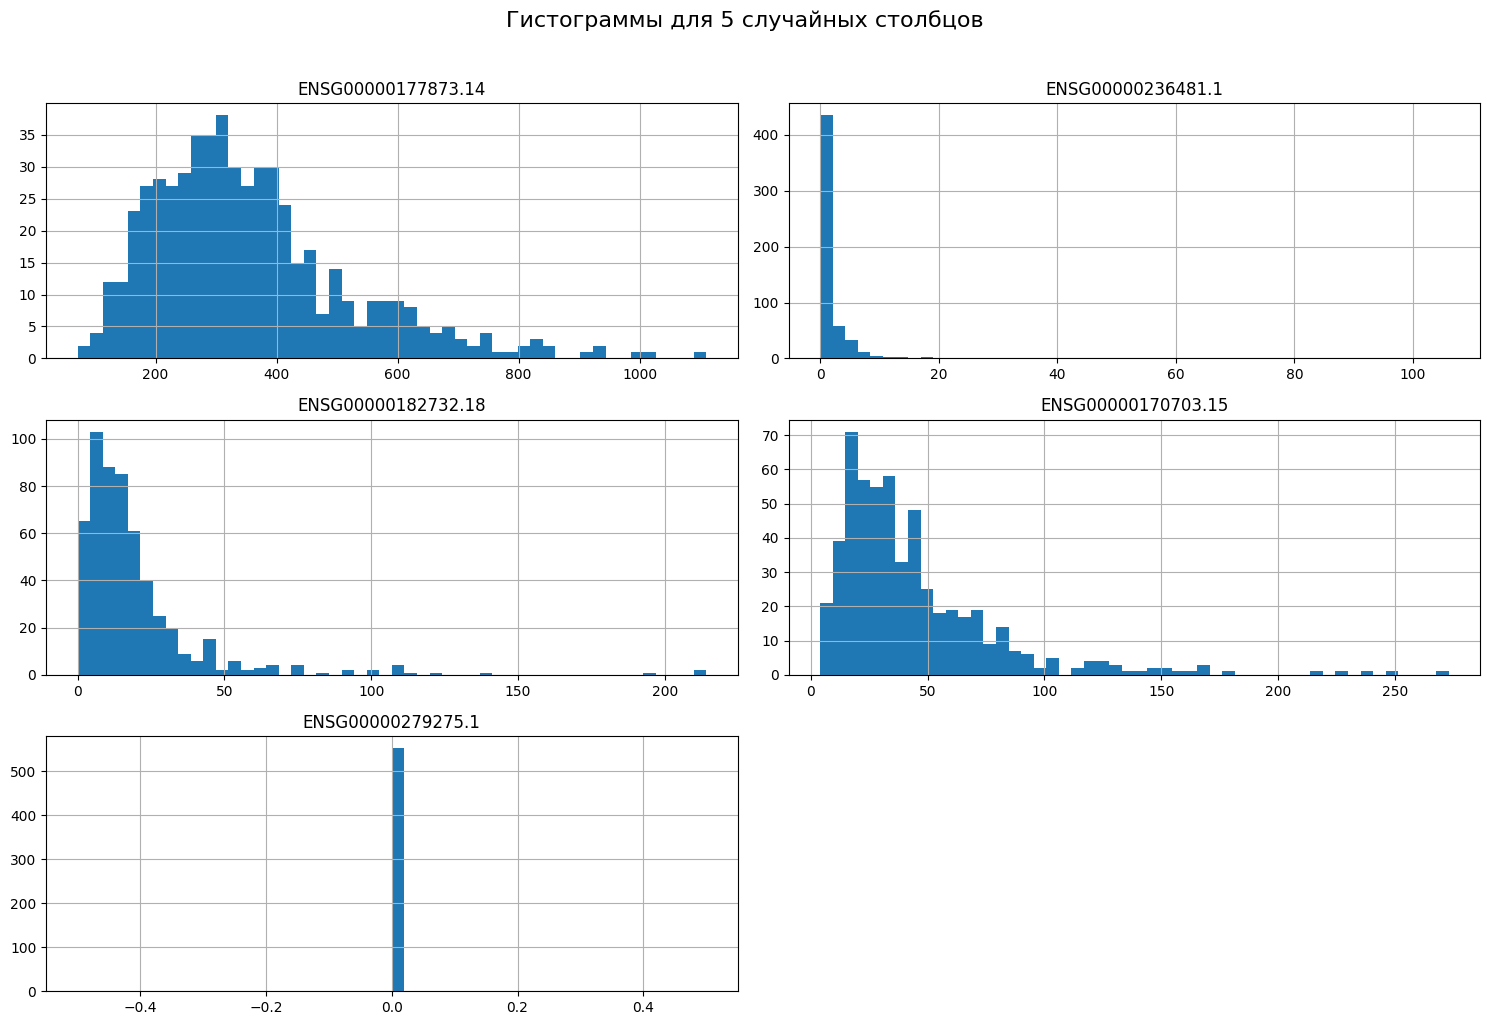

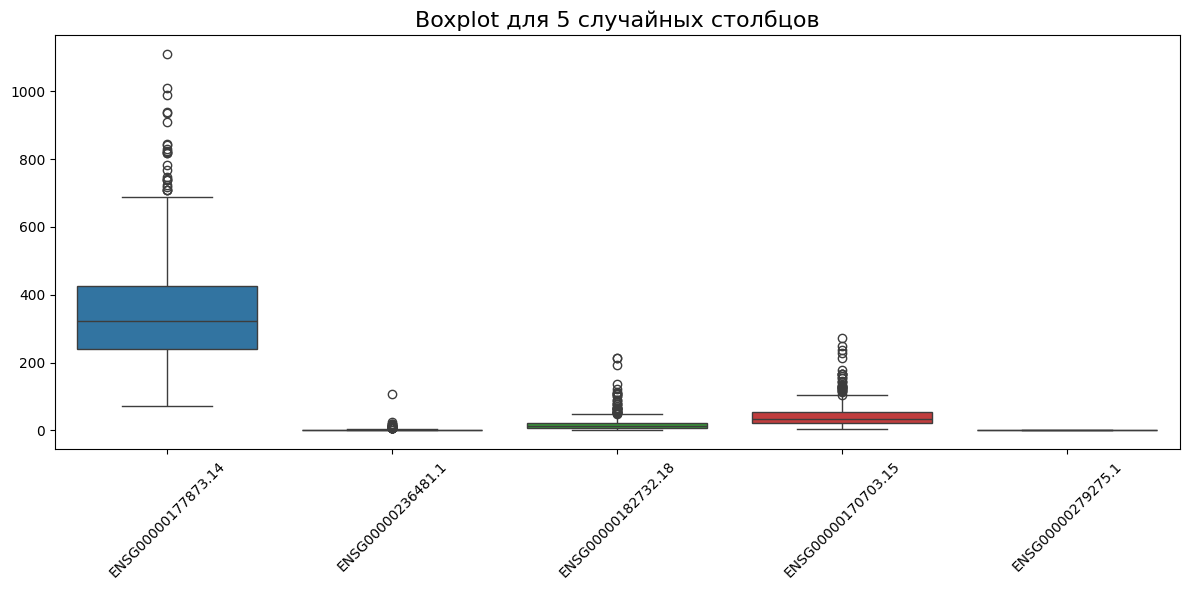

In [82]:
# Выбираем 5 случайных столбцов
np.random.seed(42)  # Для воспроизводимости
random_columns = np.random.choice(x.columns, size=5, replace=False)

# Гистограммы для 5 случайных столбцов
x[random_columns].hist(bins=50, figsize=(15, 10))
plt.suptitle('Гистограммы для 5 случайных столбцов', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

# Boxplot для 5 случайных столбцов
plt.figure(figsize=(12, 6))
sns.boxplot(data=x[random_columns])
plt.title('Boxplot для 5 случайных столбцов', fontsize=16)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [83]:
x.describe()

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
count,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,553.000000,...,553.0,553.000000,553.000000,553.0,553.000000,553.000000,553.000000,553.0,553.000000,553.000000
mean,3573.213382,22.113924,1440.437613,887.882459,187.265823,284.386980,1334.585895,2471.171790,2446.150090,1824.929476,...,0.0,0.180832,18.824593,0.0,0.468354,0.084991,307.734177,0.0,6.763110,34.589512
std,1588.387694,93.050320,454.652499,406.165824,93.648355,211.277194,1185.323163,958.921617,1135.342323,829.050715,...,0.0,1.086742,14.180896,0.0,3.804959,0.321358,130.560039,0.0,6.060679,21.639747
min,441.000000,0.000000,227.000000,151.000000,12.000000,29.000000,70.000000,449.000000,365.000000,253.000000,...,0.0,0.000000,0.000000,0.0,0.000000,0.000000,53.000000,0.0,0.000000,0.000000
25%,2459.000000,1.000000,1165.000000,593.000000,129.000000,156.000000,542.000000,1808.000000,1620.000000,1290.000000,...,0.0,0.000000,9.000000,0.0,0.000000,0.000000,220.000000,0.0,3.000000,20.000000
50%,3285.000000,5.000000,1438.000000,798.000000,174.000000,233.000000,986.000000,2368.000000,2253.000000,1711.000000,...,0.0,0.000000,16.000000,0.0,0.000000,0.000000,298.000000,0.0,6.000000,30.000000
75%,4480.000000,15.000000,1664.000000,1126.000000,232.000000,352.000000,1682.000000,2941.000000,3009.000000,2268.000000,...,0.0,0.000000,25.000000,0.0,0.000000,0.000000,386.000000,0.0,9.000000,44.000000
max,8771.000000,1693.000000,3871.000000,2499.000000,1132.000000,2438.000000,9273.000000,8543.000000,8440.000000,8743.000000,...,0.0,22.000000,118.000000,0.0,54.000000,3.000000,1284.000000,0.0,89.000000,165.000000


In [84]:
x

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288661.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288665.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288671.1,ENSG00000288674.1,ENSG00000288675.1
TCGA-KK-A7B2-01A-12R-A32O-07,2637.0,2.0,1436.0,452.0,123.0,584.0,850.0,1758.0,1975.0,857.0,...,0.0,0.0,11.0,0.0,0.0,0.0,158.0,0.0,1.0,35.0
TCGA-EJ-A8FO-01A-21R-A36G-07,4429.0,2.0,1765.0,1069.0,183.0,250.0,742.0,2857.0,2786.0,2184.0,...,0.0,0.0,5.0,0.0,0.0,0.0,337.0,0.0,3.0,17.0
TCGA-G9-6377-01A-11R-1965-07,4314.0,5.0,1454.0,845.0,149.0,279.0,722.0,3888.0,1788.0,2468.0,...,0.0,0.0,7.0,0.0,0.0,0.0,292.0,0.0,0.0,24.0
TCGA-G9-6494-01A-11R-1789-07,2907.0,3.0,1548.0,794.0,150.0,124.0,1057.0,2632.0,1976.0,2062.0,...,0.0,0.0,3.0,0.0,0.0,0.0,347.0,0.0,5.0,20.0
TCGA-G9-A9S0-01A-11R-A41O-07,1184.0,0.0,752.0,428.0,95.0,84.0,227.0,1044.0,1198.0,507.0,...,0.0,0.0,15.0,0.0,0.0,0.0,255.0,0.0,3.0,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TCGA-J4-AATV-01A-11R-A41O-07,3115.0,60.0,1393.0,735.0,187.0,485.0,1046.0,2357.0,2189.0,1501.0,...,0.0,0.0,27.0,0.0,0.0,0.0,270.0,0.0,14.0,16.0
TCGA-HC-8266-01A-11R-2263-07,4699.0,14.0,1575.0,1003.0,245.0,605.0,2028.0,2280.0,3555.0,2019.0,...,0.0,0.0,24.0,0.0,0.0,0.0,282.0,0.0,8.0,24.0
TCGA-HC-8262-01A-11R-2263-07,4835.0,0.0,2073.0,1763.0,209.0,193.0,1130.0,3680.0,2647.0,2505.0,...,0.0,0.0,40.0,0.0,1.0,0.0,437.0,0.0,4.0,31.0
TCGA-EJ-7797-01A-11R-2263-07,4222.0,5.0,1214.0,1425.0,228.0,246.0,1728.0,2890.0,2732.0,1677.0,...,0.0,0.0,20.0,0.0,0.0,0.0,317.0,0.0,3.0,31.0


удаляем столбцы из нулей

In [85]:
import pandas as pd

# Создаем маску для столбцов, которые не полностью нулевые
non_zero_columns_mask = (x != 0).any(axis=0)

# Применяем маску для фильтрации столбцов
x_filtered = x.loc[:, non_zero_columns_mask]

# Подсчет количества удаленных столбцов
counter = x.shape[1] - x_filtered.shape[1]

# Обновляем x
x = x_filtered

print(f"Удалено столбцов: {counter}")

Удалено столбцов: 3063


так как данные имеют выбросы и разные масштабы, то нормализуем

In [86]:
from sklearn.preprocessing import PowerTransformer

transformer = PowerTransformer(method='yeo-johnson')
x_normalized = transformer.fit_transform(x)
x_normalized

array([[-0.50827879, -0.54560261,  0.04290099, ..., -1.26565962,
        -1.67302447,  0.26348625],
       [ 0.62738747, -0.54560261,  0.74017672, ...,  0.34757579,
        -0.71268079, -0.9099594 ],
       [ 0.56321702,  0.03314325,  0.08231267, ...,  0.00414261,
        -2.55607918, -0.36815911],
       ...,
       [ 0.84684987, -1.63055754,  1.35524811, ...,  1.0219964 ,
        -0.38597541,  0.05588501],
       [ 0.5111958 ,  0.03314325, -0.45736522, ...,  0.19859696,
        -0.71268079,  0.05588501],
       [ 1.76621036,  1.05928099, -0.03640934, ...,  1.00321064,
        -1.12106254, -0.17532684]])

##K-best

In [87]:
print(f"x_normalized shape: {x_normalized.shape}")
print(f"x shape: {x.shape}")

x_normalized shape: (553, 57597)
x shape: (553, 57597)


In [88]:
x_norm = pd.DataFrame(data = x_normalized, columns = x.columns)
x_norm

,ENSG00000000003.15,ENSG00000000005.6,ENSG00000000419.13,ENSG00000000457.14,ENSG00000000460.17,ENSG00000000938.13,ENSG00000000971.16,ENSG00000001036.14,ENSG00000001084.13,ENSG00000001167.14,...,ENSG00000288658.1,ENSG00000288659.1,ENSG00000288660.1,ENSG00000288662.1,ENSG00000288663.1,ENSG00000288667.1,ENSG00000288669.1,ENSG00000288670.1,ENSG00000288674.1,ENSG00000288675.1
0,-0.508279,-0.545603,0.042901,-1.176930,-0.665943,1.432641,-0.160519,-0.709342,-0.281980,-1.364664,...,0.042690,-0.155158,-0.562570,-0.332328,-0.433265,-0.364961,-0.282981,-1.265660,-1.673024,0.263486
1,0.627387,-0.545603,0.740177,0.578844,0.111944,0.108169,-0.318057,0.512594,0.465962,0.569164,...,-1.465362,-0.155158,-0.562570,-0.332328,-1.298129,-0.364961,-0.282981,0.347576,-0.712681,-0.909959
2,0.563217,0.033143,0.082313,0.055152,-0.303165,0.274845,-0.349536,1.401779,-0.487707,0.866085,...,0.042690,-0.155158,-0.562570,-0.332328,-0.953435,-0.364961,-0.282981,0.004143,-2.556079,-0.368159
3,-0.314360,-0.296304,0.285607,-0.077650,-0.290093,-0.924528,0.095636,0.291465,-0.280921,0.433409,...,1.395482,-0.155158,-0.562570,-0.332328,-1.751983,-0.364961,-0.282981,0.420062,-0.112409,-0.658854
4,-1.818503,-1.630558,-1.608968,-1.274183,-1.119701,-1.474131,-1.622803,-1.810652,-1.271054,-2.226841,...,1.196673,-0.155158,1.745819,-0.332328,-0.038205,-0.364961,-0.282981,-0.303102,-0.712681,-1.422411
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,-0.171678,1.506313,-0.051908,-0.239084,0.157263,1.135553,0.083242,0.003731,-0.064333,-0.274290,...,-1.465362,-0.155158,-0.562570,-0.332328,0.797404,-0.364961,-0.282981,-0.175491,1.357701,-1.001685
549,0.774513,0.692080,0.343249,0.433388,0.751403,1.489601,0.887546,-0.080735,1.031837,0.384244,...,-0.454583,-0.155158,-0.562570,-0.332328,0.620674,-0.364961,-0.282981,-0.076456,0.518060,-0.368159
550,0.846850,-1.630558,1.355248,1.818489,0.395532,-0.279413,0.174988,1.236065,0.351016,0.903004,...,0.359153,-0.155158,-0.562570,-0.332328,1.421918,2.737409,-0.282981,1.021996,-0.385975,0.055885
551,0.511196,0.033143,-0.457365,1.269183,0.588077,0.083789,0.689312,0.544059,0.421847,-0.035096,...,0.585740,-0.155158,-0.562570,-0.332328,0.356359,-0.364961,-0.282981,0.198597,-0.712681,0.055885


###Метод локтя

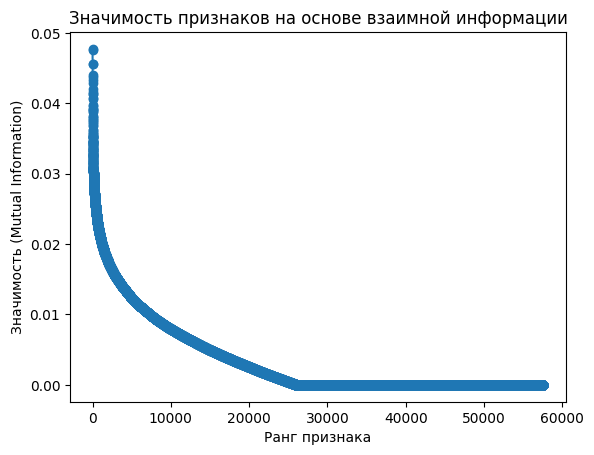

In [89]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Вычисление значимости всех признаков с использованием взаимной информации
k_best = SelectKBest(score_func=mutual_info_classif, k='all')
k_best.fit(x_norm, y)

# Значимости признаков
scores = k_best.scores_
sorted_indices = np.argsort(scores)[::-1]  # Сортируем по убыванию
sorted_scores = scores[sorted_indices]

# Визуализация значимости
plt.plot(range(1, len(sorted_scores) + 1), sorted_scores, marker='o')
plt.xlabel('Ранг признака')
plt.ylabel('Значимость (Mutual Information)')
plt.title('Значимость признаков на основе взаимной информации')
plt.show()

в этом случае сложно выбрать k по графику, поэтому используем автоматический поиск

###Автоматический поиск

In [90]:
!pip install kneed

In [91]:
from kneed import KneeLocator

# Автоматическое нахождение "локтя"
kneedle = KneeLocator(range(1, len(sorted_scores) + 1), sorted_scores, curve='convex', direction='decreasing')
optimal_k = kneedle.elbow

print(f"Оптимальное количество признаков (автоматический выбор): {optimal_k}")

Оптимальное количество признаков (автоматический выбор): 542


###Применение

In [92]:
# Применение SelectKBest с k=764
k_best = SelectKBest(score_func=mutual_info_classif, k=764)
x_new = k_best.fit_transform(x_norm, y)

# Сохранение имен отобранных признаков
selected_features = x_norm.columns[k_best.get_support()]
print("Отобранные признаки:", selected_features)

Отобранные признаки: Index(['ENSG00000001167.14', 'ENSG00000005001.10', 'ENSG00000006715.16',
       'ENSG00000008300.17', 'ENSG00000011465.18', 'ENSG00000014123.10',
       'ENSG00000033100.16', 'ENSG00000037280.16', 'ENSG00000049759.19',
       'ENSG00000064787.13',
       ...
       'ENSG00000287758.1', 'ENSG00000287780.1', 'ENSG00000287822.1',
       'ENSG00000287858.1', 'ENSG00000287912.1', 'ENSG00000287958.1',
       'ENSG00000288100.1', 'ENSG00000288330.1', 'ENSG00000288564.1',
       'ENSG00000288612.1'],
      dtype='object', length=764)


In [93]:
kb_features = pd.DataFrame(selected_features)
kb_features

,0
0,ENSG00000001167.14
1,ENSG00000005001.10
2,ENSG00000006715.16
3,ENSG00000008300.17
4,ENSG00000011465.18
...,...
759,ENSG00000287958.1
760,ENSG00000288100.1
761,ENSG00000288330.1
762,ENSG00000288564.1


###K-Best датасет

In [94]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

In [95]:
kb_df = pd.DataFrame(data = x_new, columns = ['KB-{}'.format(i) for i in range(1, kb_features.size + 1)])
kb_df['KB-Y'] = label_encoder.fit_transform(y)
kb_df

,KB-1,KB-2,KB-3,KB-4,KB-5,KB-6,KB-7,KB-8,KB-9,KB-10,...,KB-756,KB-757,KB-758,KB-759,KB-760,KB-761,KB-762,KB-763,KB-764,KB-Y
0,-1.364664,1.051398,-1.261234,-1.218139,0.023387,-1.302299,-0.088808,0.100663,-0.380747,-0.552463,...,-0.525168,-1.113512,-0.604204,-0.259938,1.454465,-1.003282,-0.135706,-0.042563,0.499689,0
1,0.569164,0.131439,0.349535,0.333577,-0.131771,0.896310,0.625014,0.773811,0.968360,0.983451,...,-0.045617,0.683808,-0.604204,-0.259938,1.053112,0.873892,-0.135706,-0.042563,-0.420969,0
2,0.866085,0.776016,-0.264826,-0.566701,-0.163534,-0.044208,0.998402,-0.781389,0.666223,0.111004,...,0.604196,-1.113512,-0.604204,-0.259938,-0.782156,-1.003282,-0.135706,-0.042563,-2.300722,0
3,0.433409,-1.391929,0.552372,-2.647094,0.729748,0.427664,-0.106163,-0.072558,0.474571,1.653684,...,-0.664343,0.147980,-0.604204,-0.259938,-0.782156,0.649866,-0.135706,-0.042563,-2.480460,0
4,-2.226841,-0.077741,-1.343796,1.730646,-1.383768,-1.405335,-0.971876,-1.487209,-0.849148,0.985271,...,-0.975354,-1.113512,-0.604204,-0.259938,-0.782156,-1.749918,-0.135706,-0.042563,-0.470628,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
548,-0.274290,2.431820,0.193686,-0.256044,-0.218340,-0.585142,0.309604,0.190826,-0.532521,0.741680,...,-0.664343,-1.113512,-0.604204,-0.259938,-0.782156,1.294407,-0.135706,-0.042563,1.269289,0
549,0.384244,0.169314,0.411807,-0.296866,0.282061,-0.209841,-0.662602,0.535658,-0.246951,-0.372481,...,0.159633,0.994977,1.621957,-0.259938,1.053112,0.518758,-0.135706,-0.042563,1.010643,0
550,0.903004,0.392575,0.523879,0.730906,-0.368137,0.192669,1.033964,-0.515983,0.091143,0.948813,...,-0.525168,1.945507,-0.604204,-0.259938,-0.782156,0.873892,-0.135706,-0.042563,0.830863,0
551,-0.035096,0.405029,0.014584,1.091028,-0.484854,0.838966,0.946469,0.279382,0.724573,-0.085131,...,-0.664343,0.994977,1.621957,-0.259938,-0.782156,0.767386,-0.135706,-0.042563,-0.153178,0


Проверка на Nan

In [96]:
kb_df.isna().sum().sum()

np.int64(0)

Матрица корреляции KB-признаков с тагретной переменной

In [97]:
# Проверка типов данных всех столбцов
print(kb_df.dtypes)

KB-1      float64
KB-2      float64
KB-3      float64
KB-4      float64
KB-5      float64
           ...   
KB-761    float64
KB-762    float64
KB-763    float64
KB-764    float64
KB-Y        int64
Length: 765, dtype: object


Стоит расшифровать, какие это признаки в оригинальном датасете

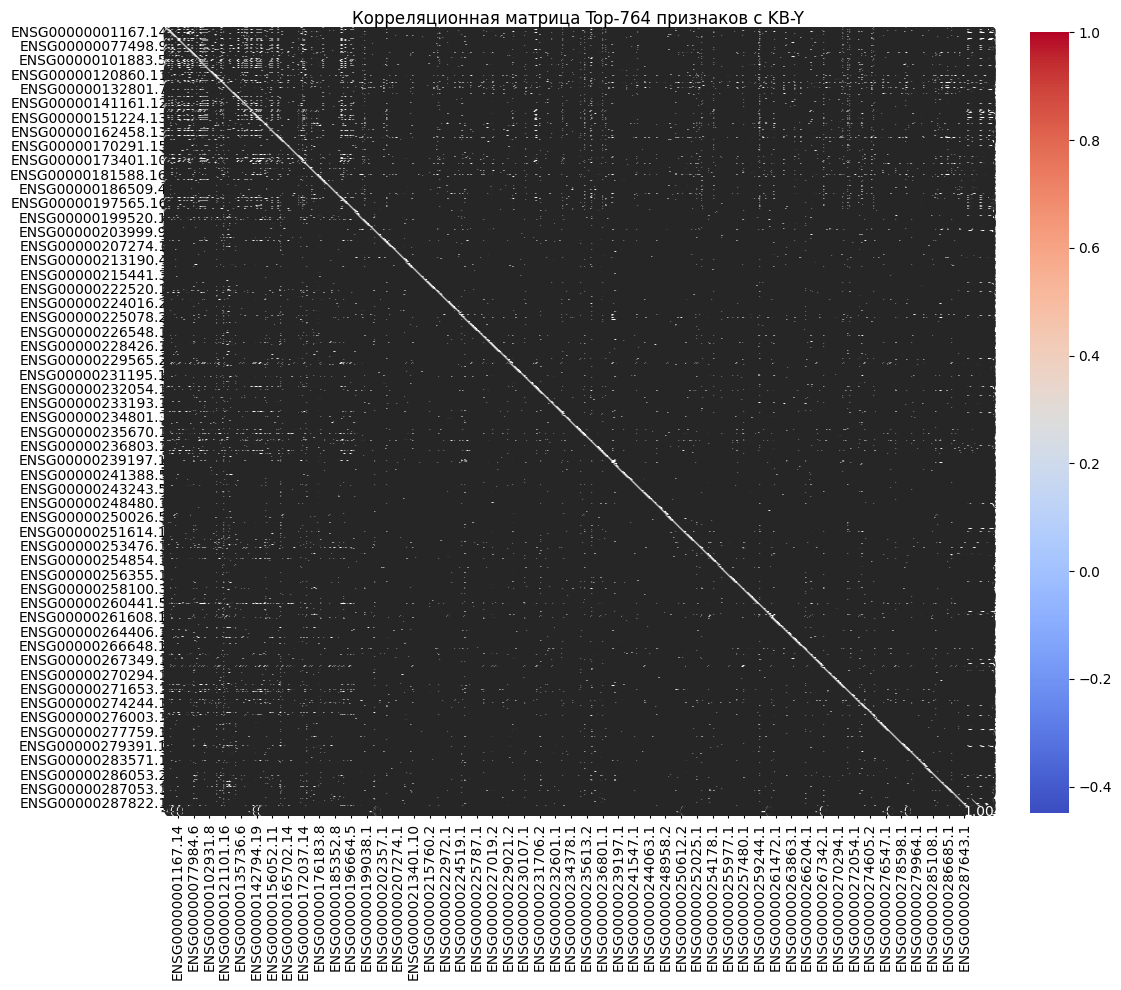

In [100]:
# Предполагается, что selected_features уже определены
top_features_names = selected_features.tolist()

# Создаем датафрейм с выбранными признаками и целевой переменной
df_top = x_norm[top_features_names].copy()

# Кодируем целевую переменную, если она еще не закодирована
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df_top['KB-Y'] = label_encoder.fit_transform(y)

# Вычисляем корреляционную матрицу
corr_matrix = df_top.corr()

# Визуализация
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title(f'Корреляционная матрица Top-{len(top_features_names)} признаков с KB-Y')
plt.tight_layout()
plt.show()

In [103]:
corMatKB = kb_df.corr().drop('KB-Y')
targetCorKB = corMatKB['KB-Y'].to_frame(name='ReccurenceCorrelation')
targetCorKB = targetCorKB.sort_values(by = 'ReccurenceCorrelation', ascending = False, key = abs)
targetCorKB.style.background_gradient(vmin=-1, vmax=1)

,ReccurenceCorrelation
KB-513,0.208717
KB-718,0.199694
KB-674,0.168548
KB-355,0.168548
KB-673,0.166293
KB-574,-0.155472
KB-743,0.145564
KB-84,-0.125921
KB-689,-0.123294
KB-492,-0.121157


#Разделение на тренировочные и тестовые выборки


Делим новый датасет на тренировочные и тестовые выборки

In [104]:
kb_x_train, kb_x_test, kb_y_train, kb_y_test = train_test_split(kb_df.drop(columns = 'KB-Y'), kb_df['KB-Y'], train_size=0.8, random_state = 42)
print(kb_x_train, kb_x_test, kb_y_train, kb_y_test)

         KB-1      KB-2      KB-3      KB-4      KB-5      KB-6      KB-7  \
18   0.394594 -1.332447 -1.605039  0.604076 -1.485651 -0.353015 -1.168714   
325 -1.081304 -0.672834 -0.585498 -0.063386  0.612298 -0.010184  1.182658   
486  0.760226  0.741003  0.413050  0.866904 -0.492397 -0.008232 -0.274255   
296  0.556046 -0.986781  0.586992 -0.777613 -1.277314 -0.543370 -0.851916   
478 -0.342854 -0.549888 -0.224300 -0.660366 -0.416261  0.408841 -0.237169   
..        ...       ...       ...       ...       ...       ...       ...   
71   1.634272 -0.145552  0.749966  1.940783 -1.119057  1.017162  1.240093   
106 -0.379184 -0.491348 -1.069691 -0.471195  0.223617 -1.340081  0.052716   
270  1.260260 -0.122696  2.264772 -0.248098  1.116804  1.023926  0.919740   
435  0.052684  0.292207  0.619450 -0.926096  0.062646  0.235120 -0.504567   
102  0.436813  0.942401  0.822082  1.835765  1.183776  0.263317  1.389327   

         KB-8      KB-9     KB-10  ...    KB-755    KB-756    KB-757  \
18 

In [105]:
kb_y_train.nunique()

2

переводим тагреты в категориальные признаки для модели

In [106]:
kb_y_train = kb_y_train.astype('category').cat.codes
kb_y_test = kb_y_test.astype('category').cat.codes

#Модель1
**Логистическая регрессия** — это статистическая модель, используемая для решения задач бинарной классификации. Логистическая регрессия основана на понятии логистической функции (сигмоидальной функции), которая преобразует входные признаки в вероятность принадлежности объекта к одному из классов.

In [119]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    classification_report,
    precision_recall_curve,
    average_precision_score
)

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, cross_val_score

In [120]:
# Обучение модели логистической регрессии с подбором гиперпараметров
# Определение диапазона гиперпараметров для GridSearchCV
param_grid = {
    'C': np.logspace(-4, 4, 20),          # Коэффициент регуляризации
    'penalty': ['l1', 'l2'],             # Тип регуляризации
    'solver': ['liblinear']               # Подходящий солвер для l1 и l2
}

In [121]:
kb_model_lr = LogisticRegression(max_iter=1000)
# Инициализация GridSearchCV
grid_search = GridSearchCV(
    estimator=kb_model_lr,
    param_grid=param_grid,
    cv=5,                                 # 5-кратная кросс-валидация
    scoring='roc_auc',                    # Метрика для оценки
    n_jobs=-1,                            # Использовать все доступные ядра
    verbose=1
)

# Обучение модели с подбором гиперпараметров
grid_search.fit(kb_x_train, kb_y_train)

# Лучшие параметры
print("Лучшие параметры:", grid_search.best_params_)
print("Лучший AUC на кросс-валидации:", grid_search.best_score_)

# Получение лучшей модели
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 40 candidates, totalling 200 fits
Лучшие параметры: {'C': np.float64(3792.690190732246), 'penalty': 'l1', 'solver': 'liblinear'}
Лучший AUC на кросс-валидации: 0.7614967185816436


In [122]:
# 3. Предсказания на тестовой выборке
kb_predict_lr = best_model.predict(kb_x_test)
kb_prob_lr = best_model.predict_proba(kb_x_test)[:, 1]

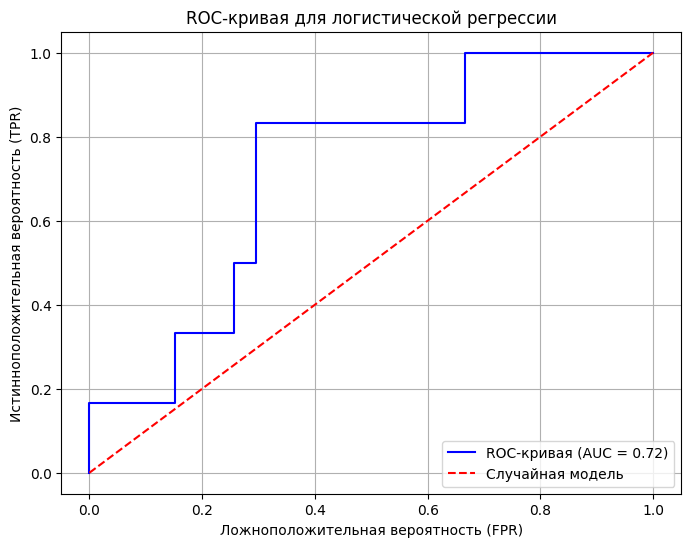

In [123]:
# 4.1. ROC-кривая и AUC
fpr, tpr, thresholds = roc_curve(kb_y_test, kb_prob_lr)
auc_score = roc_auc_score(kb_y_test, kb_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f'ROC-кривая (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель')
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('ROC-кривая для логистической регрессии')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

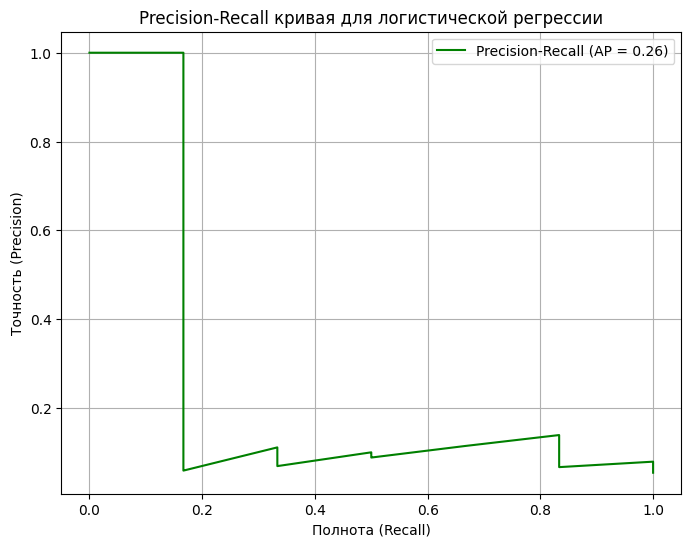

In [124]:
# 4.2. Precision-Recall кривая и Average Precision Score
precision, recall, thresholds_pr = precision_recall_curve(kb_y_test, kb_prob_lr)
average_precision = average_precision_score(kb_y_test, kb_prob_lr)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', label=f'Precision-Recall (AP = {average_precision:.2f})')
plt.xlabel('Полнота (Recall)')
plt.ylabel('Точность (Precision)')
plt.title('Precision-Recall кривая для логистической регрессии')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

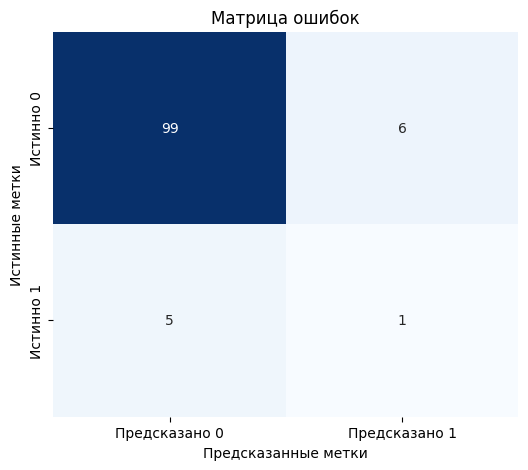

In [125]:
# 4.3. Матрица ошибок
cm = confusion_matrix(kb_y_test, kb_predict_lr)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Истинно 0', 'Истинно 1'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок')
plt.show()

In [126]:
# 4.4. Отчет по классификации
print("\nОтчет по классификации:")
print(classification_report(kb_y_test, kb_predict_lr))


Отчет по классификации:
              precision    recall  f1-score   support

           0       0.95      0.94      0.95       105
           1       0.14      0.17      0.15         6

    accuracy                           0.90       111
   macro avg       0.55      0.55      0.55       111
weighted avg       0.91      0.90      0.90       111



<ipython-input-127-e8be6f2fde3d>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')


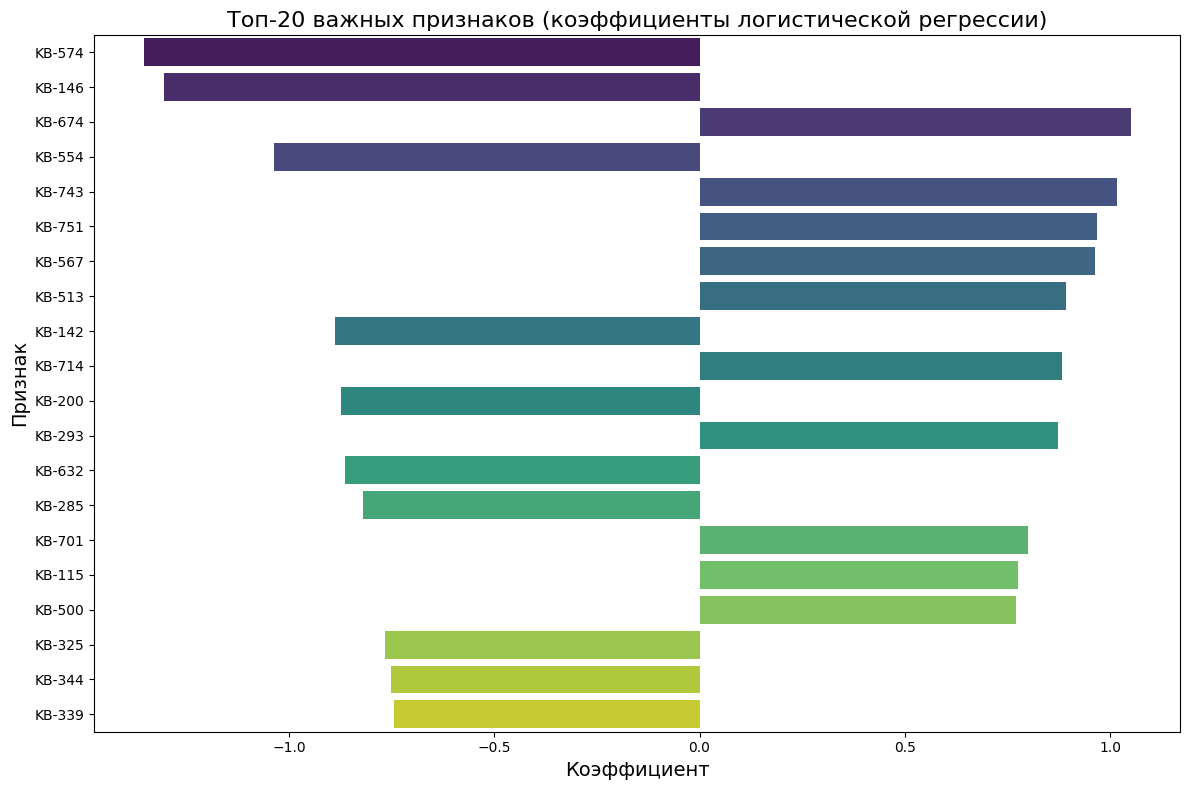

In [127]:
# 5. Важность признаков (коэффициенты модели)
if isinstance(kb_x_train, pd.DataFrame):
    feature_names = kb_x_train.columns
else:
    feature_names = [f'Feature {i}' for i in range(kb_x_train.shape[1])]

coefficients = best_model.coef_[0]
feature_importance = pd.Series(coefficients, index=feature_names).sort_values(key=abs, ascending=False)

top_n = 20
top_features = feature_importance.iloc[:top_n]

plt.figure(figsize=(12, 8))  # Увеличенный размер графика
sns.barplot(x=top_features.values, y=top_features.index, palette='viridis')
plt.title(f'Топ-{top_n} важных признаков (коэффициенты логистической регрессии)', fontsize=16)
plt.xlabel('Коэффициент', fontsize=14)
plt.ylabel('Признак', fontsize=14)
plt.tight_layout()
plt.show()

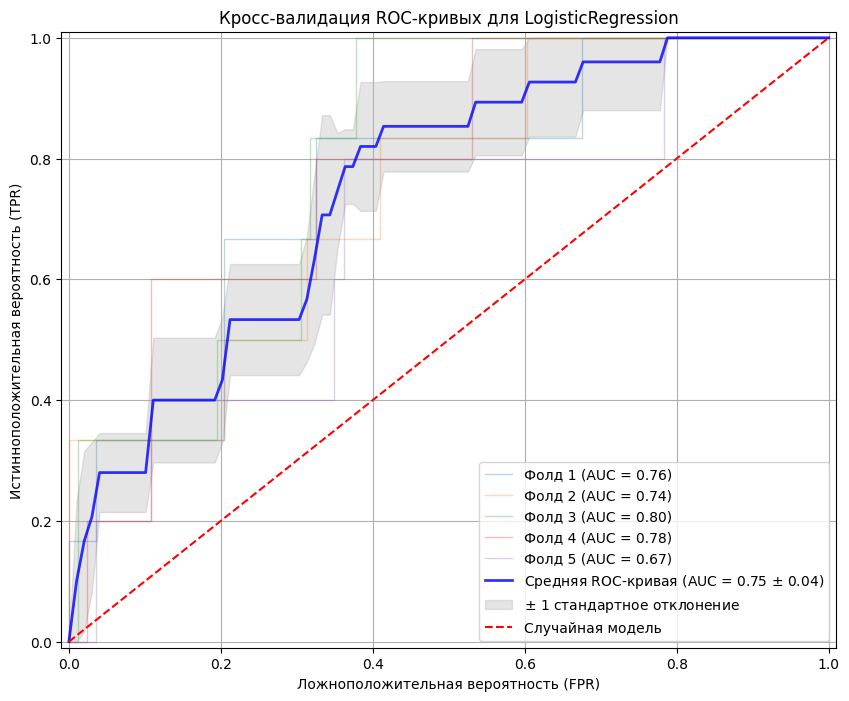


Средний AUC на кросс-валидации для LogisticRegression: 0.75 ± 0.04


In [128]:
# Инициализация StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создание фигуры для ROC-кривых
plt.figure(figsize=(10, 8))

# Инициализация переменных для среднего ROC
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
fold = 1

for train_index, test_index in skf.split(kb_x_train, kb_y_train):
    X_train_fold, X_test_fold = kb_x_train.iloc[train_index], kb_x_train.iloc[test_index]
    y_train_fold, y_test_fold = kb_y_train.iloc[train_index], kb_y_train.iloc[test_index]

    # Обучение модели на текущем фолде
    best_model.fit(X_train_fold, y_train_fold)

    # Предсказание вероятностей на валидационном фолде
    y_prob_fold = best_model.predict_proba(X_test_fold)[:, 1]

    # Вычисление ROC-кривой и AUC для текущего фолда
    fpr, tpr, thresholds = roc_curve(y_test_fold, y_prob_fold)
    roc_auc = roc_auc_score(y_test_fold, y_prob_fold)
    aucs.append(roc_auc)

    # Интерполяция TPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Построение ROC-кривой для текущего фолда
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Фолд {fold} (AUC = {roc_auc:.2f})')
    fold += 1

# Построение средней ROC-кривой
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)  # Используем среднее значение AUC из фолдов
std_auc = np.std(aucs)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Средняя ROC-кривая (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=0.8)

# Построение стандартного отклонения
std_tpr = np.std(tprs, axis=0)
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='grey', alpha=0.2,
                 label=r'$\pm$ 1 стандартное отклонение')

# Дополнение графика
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('Кросс-валидация ROC-кривых для LogisticRegression')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Вывод средней и стандартной метрики AUC
print(f'\nСредний AUC на кросс-валидации для LogisticRegression: {np.mean(aucs):.2f} ± {np.std(aucs):.2f}')

#Модель2
**Случайный лес** — это метод машинного обучения, основанный на идее построения множества Decision Trees (деревьев решений) и комбинирования их результатов для получения более точного и надежного предсказания.

In [129]:
# 2. Обучение модели RandomForestClassifier с подбором гиперпараметров

# Определение диапазона гиперпараметров для GridSearchCV
param_grid = {
    'n_estimators': [100, 200, 300],              # Количество деревьев в лесу
    'max_depth': [None, 10, 20, 30],             # Максимальная глубина дерева
    'min_samples_split': [2, 5, 10],             # Минимальное количество образцов для разбиения узла
    'min_samples_leaf': [1, 2, 4],               # Минимальное количество образцов в листовом узле
    'bootstrap': [True, False]                    # Использование бутстрэппинга
}

# Инициализация RandomForestClassifier
rf_clf = RandomForestClassifier(random_state=42)

# Инициализация GridSearchCV
grid_search_rf = GridSearchCV(
    estimator=rf_clf,
    param_grid=param_grid,
    cv=5,                                         # 5-кратная кросс-валидация
    scoring='roc_auc',                            # Метрика для оценки
    n_jobs=-1,                                    # Использовать все доступные ядра
    verbose=2
)

# Обучение модели с подбором гиперпараметров
grid_search_rf.fit(kb_x_train, kb_y_train)

# Вывод лучших параметров и лучшего результата
print("\nЛучшие параметры для RandomForestClassifier:", grid_search_rf.best_params_)
print("Лучший AUC на кросс-валидации:", grid_search_rf.best_score_)

# Получение лучшей модели
best_rf_model = grid_search_rf.best_estimator_

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Лучшие параметры для RandomForestClassifier: {'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
Лучший AUC на кросс-валидации: 0.8343020863943579


In [130]:
# 3. Предсказания на тестовой выборке
kb_predict_rf = best_rf_model.predict(kb_x_test)
kb_prob_rf = best_rf_model.predict_proba(kb_x_test)[:, 1]

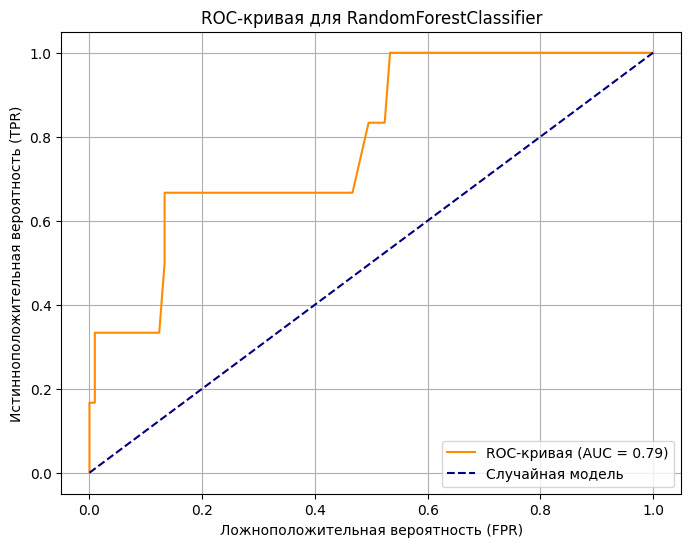

In [131]:
# 4.1. ROC-кривая и AUC
fpr_rf, tpr_rf, thresholds_rf = roc_curve(kb_y_test, kb_prob_rf)
auc_score_rf = roc_auc_score(kb_y_test, kb_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_rf, tpr_rf, color='darkorange', label=f'ROC-кривая (AUC = {auc_score_rf:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Случайная модель')
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('ROC-кривая для RandomForestClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

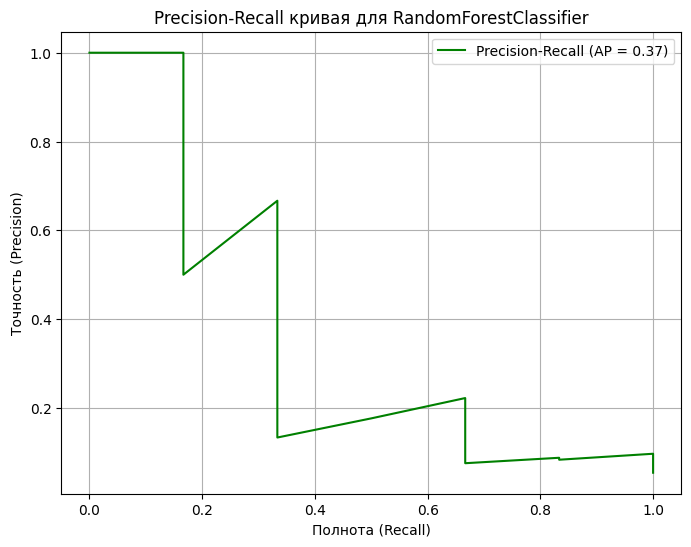

In [132]:
# 4.2. Precision-Recall кривая и Average Precision Score
precision_rf, recall_rf, thresholds_pr_rf = precision_recall_curve(kb_y_test, kb_prob_rf)
average_precision_rf = average_precision_score(kb_y_test, kb_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(recall_rf, precision_rf, color='green', label=f'Precision-Recall (AP = {average_precision_rf:.2f})')
plt.xlabel('Полнота (Recall)')
plt.ylabel('Точность (Precision)')
plt.title('Precision-Recall кривая для RandomForestClassifier')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

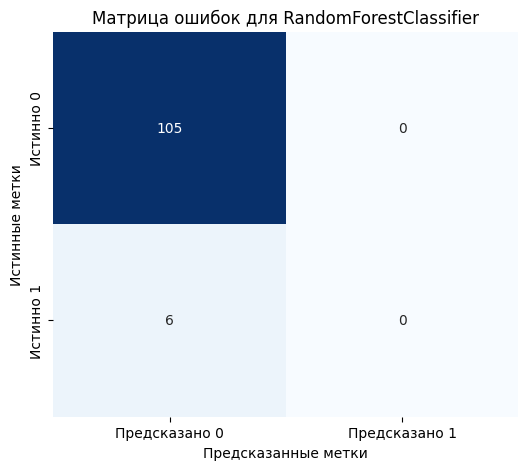

In [133]:
# 4.3. Матрица ошибок
cm_rf = confusion_matrix(kb_y_test, kb_predict_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Истинно 0', 'Истинно 1'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для RandomForestClassifier')
plt.show()

In [134]:
# 4.4. Отчет по классификации
print("\nОтчет по классификации для RandomForestClassifier:")
print(classification_report(kb_y_test, kb_predict_rf))


Отчет по классификации для RandomForestClassifier:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       105
           1       0.00      0.00      0.00         6

    accuracy                           0.95       111
   macro avg       0.47      0.50      0.49       111
weighted avg       0.89      0.95      0.92       111



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [135]:
# 6. Кросс-валидация на тренировочной выборке (опционально)
cv_scores_rf = cross_val_score(best_rf_model, kb_x_train, kb_y_train, cv=5, scoring='roc_auc')
print(f'\nСредний AUC на кросс-валидации для RandomForestClassifier: {cv_scores_rf.mean():.2f} ± {cv_scores_rf.std():.2f}')


Средний AUC на кросс-валидации для RandomForestClassifier: 0.83 ± 0.09


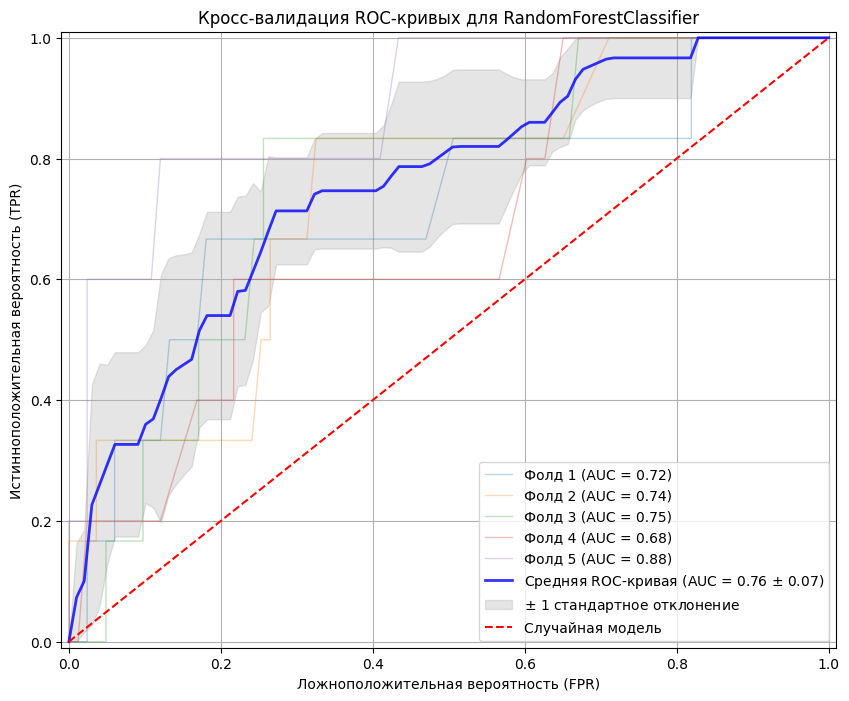


Средний AUC на кросс-валидации для RandomForestClassifier: 0.76 ± 0.07


In [136]:
# 6. Кросс-валидация на тренировочной выборке (опционально)
# Вместо использования cross_val_score для получения общей оценки, мы проведём кросс-валидацию и построим ROC-кривые для каждого фолда
# Используем StratifiedKFold для стратифицированного разбиения

# Инициализация StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создание фигуры для ROC-кривых
plt.figure(figsize=(10, 8))

# Инициализация переменных для среднего ROC
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
fold = 1

for train_index, test_index in skf.split(kb_x_train, kb_y_train):
    X_train_fold, X_test_fold = kb_x_train.iloc[train_index], kb_x_train.iloc[test_index]
    y_train_fold, y_test_fold = kb_y_train.iloc[train_index], kb_y_train.iloc[test_index]

    # Обучение модели на текущем фолде
    best_rf_model.fit(X_train_fold, y_train_fold)

    # Предсказание вероятностей на валидационном фолде
    y_prob_fold = best_rf_model.predict_proba(X_test_fold)[:, 1]

    # Вычисление ROC-кривой и AUC для текущего фолда
    fpr, tpr, thresholds = roc_curve(y_test_fold, y_prob_fold)
    roc_auc = roc_auc_score(y_test_fold, y_prob_fold)
    aucs.append(roc_auc)

    # Интерполяция TPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Построение ROC-кривой для текущего фолда
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Фолд {fold} (AUC = {roc_auc:.2f})')
    fold += 1

# Построение средней ROC-кривой
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)  # Используем среднее значение из фолдов
std_auc = np.std(aucs)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Средняя ROC-кривая (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=0.8)

# Построение стандартного отклонения
std_tpr = np.std(tprs, axis=0)
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='grey', alpha=0.2,
                 label=r'$\pm$ 1 стандартное отклонение')

# Дополнение графика
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('Кросс-валидация ROC-кривых для RandomForestClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Вывод средней и стандартной метрики AUC
print(f'\nСредний AUC на кросс-валидации для RandomForestClassifier: {np.mean(aucs):.2f} ± {np.std(aucs):.2f}')

#Модель3
**Градиентный бустинг** — это метод обучения на основе ансамбля, используемый для решения задач классификации, регрессии и других типов задач машинного обучения. Он основан на идее построения последовательности слабых моделирующих функций (например, деревьев решений), каждая из которых пытается исправить ошибки предыдущих моделей. Градиентный бустинг является разновидностью бустинга, отличающейся тем, что каждая последующая модель обучается на градиенте ошибки предыдущей модели.

In [137]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_score, train_test_split

In [138]:
# 2. Обучение модели GradientBoostingClassifier с подбором гиперпараметров

# Определение диапазона гиперпараметров для RandomizedSearchCV
param_distributions_gb = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'subsample': [0.8, 1.0],
    'max_features': ['sqrt', 'log2', None]  # Исключаем 'auto'
}

# Инициализация GradientBoostingClassifier
gb_clf = GradientBoostingClassifier(random_state=42)

# Инициализация RandomizedSearchCV
random_search_gb = RandomizedSearchCV(
    estimator=gb_clf,
    param_distributions=param_distributions_gb,
    n_iter=50,                                 # Количество случайных комбинаций
    cv=5,                                      # 5-кратная кросс-валидация
    scoring='roc_auc',                         # Метрика для оценки
    n_jobs=-1,                                 # Использовать все доступные ядра
    verbose=2,
    random_state=42,
    error_score='raise'                        # Поднять ошибку для отладки
)

try:
    # Обучение модели с подбором гиперпараметров
    random_search_gb.fit(kb_x_train, kb_y_train)
except Exception as e:
    print("Произошла ошибка при обучении:", e)
    # Для отладки можно установить error_score='raise' в RandomizedSearchCV и проанализировать ошибку
    raise

# Вывод лучших параметров и лучшего результата
print("\nЛучшие параметры для GradientBoostingClassifier:", random_search_gb.best_params_)
print("Лучший AUC на кросс-валидации:", random_search_gb.best_score_)

# Получение лучшей модели
best_gb_model = random_search_gb.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Лучшие параметры для GradientBoostingClassifier: {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.2}
Лучший AUC на кросс-валидации: 0.8702076599079243


In [139]:
# 3. Предсказания на тестовой выборке
kb_predict_gb = best_gb_model.predict(kb_x_test)
kb_prob_gb = best_gb_model.predict_proba(kb_x_test)[:, 1]

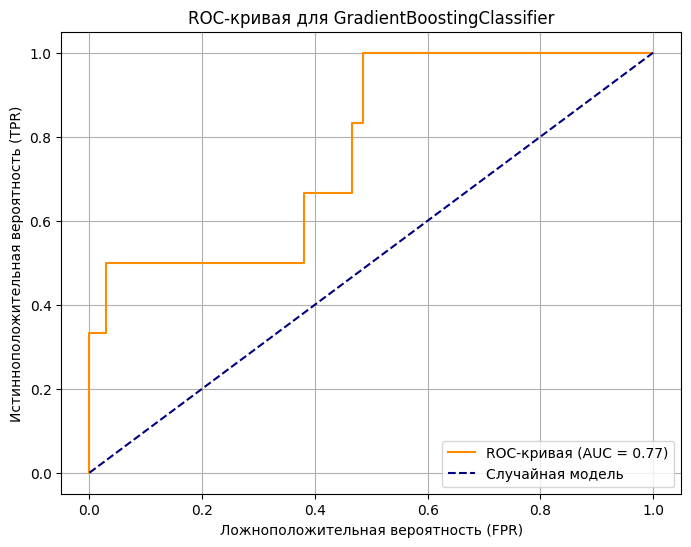

In [140]:
# 4.1. ROC-кривая и AUC
fpr_gb, tpr_gb, thresholds_gb = roc_curve(kb_y_test, kb_prob_gb)
auc_score_gb = roc_auc_score(kb_y_test, kb_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, color='darkorange', label=f'ROC-кривая (AUC = {auc_score_gb:.2f})')
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Случайная модель')
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('ROC-кривая для GradientBoostingClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

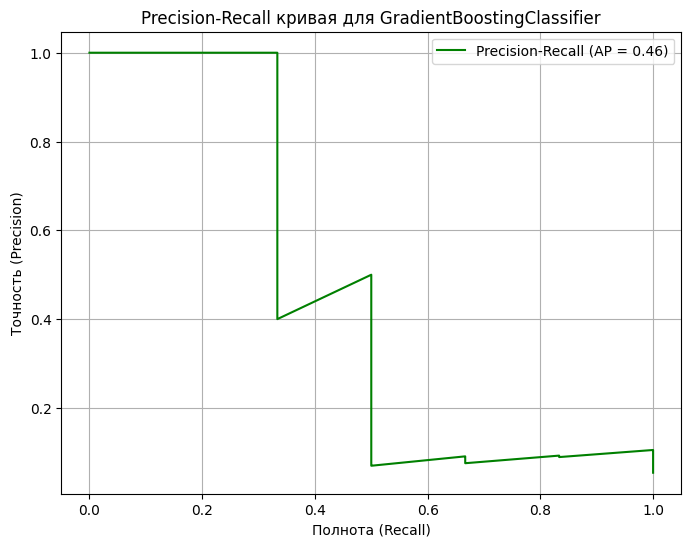

In [141]:

# 4.2. Precision-Recall кривая и Average Precision Score
precision_gb, recall_gb, thresholds_pr_gb = precision_recall_curve(kb_y_test, kb_prob_gb)
average_precision_gb = average_precision_score(kb_y_test, kb_prob_gb)

plt.figure(figsize=(8, 6))
plt.plot(recall_gb, precision_gb, color='green', label=f'Precision-Recall (AP = {average_precision_gb:.2f})')
plt.xlabel('Полнота (Recall)')
plt.ylabel('Точность (Precision)')
plt.title('Precision-Recall кривая для GradientBoostingClassifier')
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

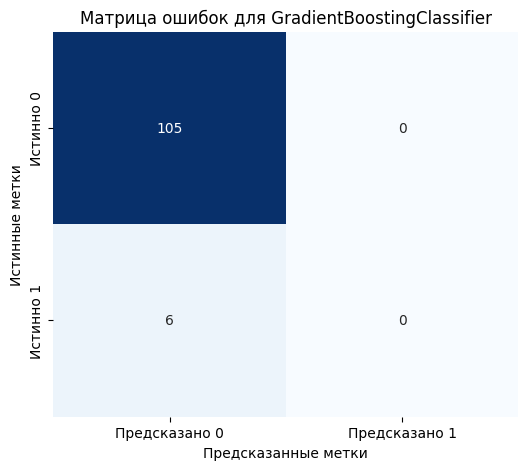

In [142]:
# 4.3. Матрица ошибок
cm_gb = confusion_matrix(kb_y_test, kb_predict_gb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Предсказано 0', 'Предсказано 1'],
            yticklabels=['Истинно 0', 'Истинно 1'])
plt.xlabel('Предсказанные метки')
plt.ylabel('Истинные метки')
plt.title('Матрица ошибок для GradientBoostingClassifier')
plt.show()

In [143]:
# 4.4. Отчет по классификации
print("\nОтчет по классификации для GradientBoostingClassifier:")
print(classification_report(kb_y_test, kb_predict_gb))


Отчет по классификации для GradientBoostingClassifier:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97       105
           1       0.00      0.00      0.00         6

    accuracy                           0.95       111
   macro avg       0.47      0.50      0.49       111
weighted avg       0.89      0.95      0.92       111



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [144]:
from sklearn.model_selection import StratifiedKFold

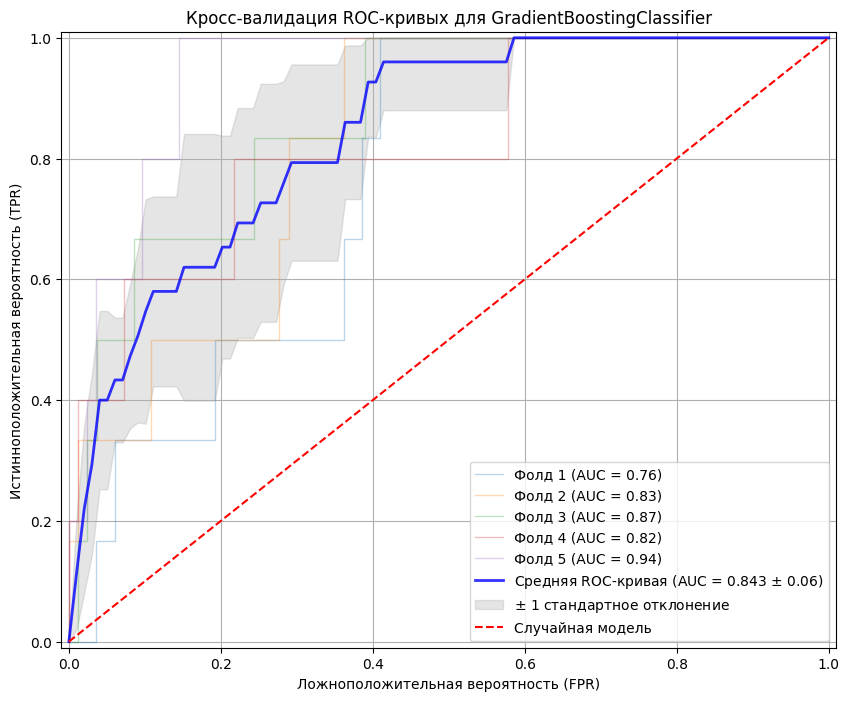


Средний AUC на кросс-валидации для GradientBoostingClassifier: 0.84 ± 0.06


In [145]:
# Инициализация StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создание фигуры для ROC-кривых
plt.figure(figsize=(10, 8))

# Инициализация переменных для среднего ROC
mean_fpr = np.linspace(0, 1, 100)
tprs = []
aucs = []
fold = 1

for train_index, test_index in skf.split(kb_x_train, kb_y_train):
    X_train_fold, X_test_fold = kb_x_train.iloc[train_index], kb_x_train.iloc[test_index]
    y_train_fold, y_test_fold = kb_y_train.iloc[train_index], kb_y_train.iloc[test_index]

    # Обучение модели на текущем фолде
    best_gb_model.fit(X_train_fold, y_train_fold)

    # Предсказание вероятностей на валидационном фолде
    y_prob_fold = best_gb_model.predict_proba(X_test_fold)[:, 1]

    # Вычисление ROC-кривой и AUC для текущего фолда
    fpr, tpr, thresholds = roc_curve(y_test_fold, y_prob_fold)
    roc_auc = roc_auc_score(y_test_fold, y_prob_fold)
    aucs.append(roc_auc)

    # Интерполяция TPR
    interp_tpr = np.interp(mean_fpr, fpr, tpr)
    interp_tpr[0] = 0.0
    tprs.append(interp_tpr)

    # Построение ROC-кривой для текущего фолда
    plt.plot(fpr, tpr, lw=1, alpha=0.3, label=f'Фолд {fold} (AUC = {roc_auc:.2f})')
    fold += 1

# Построение средней ROC-кривой
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = np.mean(aucs)  # Используем среднее значение из фолдов вместо оценки на всем наборе
std_auc = np.std(aucs)
plt.plot(mean_fpr, mean_tpr, color='b',
         label=r'Средняя ROC-кривая (AUC = %0.3f $\pm$ %0.2f)' % (mean_auc, std_auc),
         lw=2, alpha=0.8)

# Построение стандартного отклонения
std_tpr = np.std(tprs, axis=0)
tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color='grey', alpha=0.2,
                 label=r'$\pm$ 1 стандартное отклонение')

# Дополнение графика
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Случайная модель')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Ложноположительная вероятность (FPR)')
plt.ylabel('Истинноположительная вероятность (TPR)')
plt.title('Кросс-валидация ROC-кривых для GradientBoostingClassifier')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Вывод средней и стандартной метрики AUC
print(f'\nСредний AUC на кросс-валидации для GradientBoostingClassifier: {np.mean(aucs):.2f} ± {np.std(aucs):.2f}')

### Общее сравнение моделей - логистическая регрессия, случайный лес, градиентный бустинг.


Обучение модели: LogisticRegression
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры для LogisticRegression: {'solver': 'saga', 'penalty': 'l2', 'class_weight': None, 'C': np.float64(0.03359818286283781)}
Лучший AUC на кросс-валидации: 0.81


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(



Обучение модели: RandomForestClassifier
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры для RandomForestClassifier: {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None, 'bootstrap': False}
Лучший AUC на кросс-валидации: 0.83

Обучение модели: GradientBoostingClassifier
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Лучшие параметры для GradientBoostingClassifier: {'subsample': 1.0, 'n_estimators': 400, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 3, 'learning_rate': 0.2}
Лучший AUC на кросс-валидации: 0.87


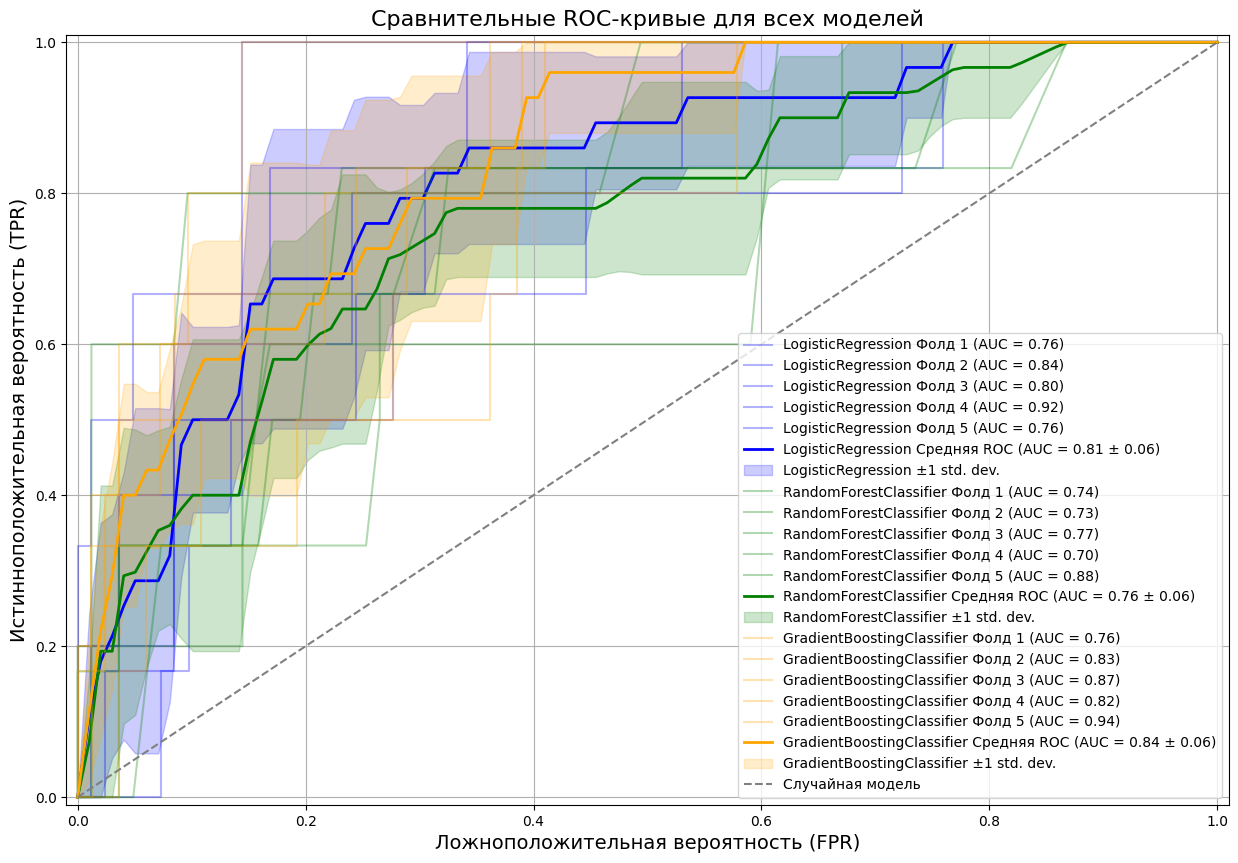

In [146]:
# 2. Определение моделей и их параметров для RandomizedSearchCV
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'param_distributions': {
            'C': np.logspace(-4, 4, 20),          # Коэффициент регуляризации
            'penalty': ['l1', 'l2'],             # Тип регуляризации
            'solver': ['liblinear', 'saga'],      # Подходящие солверы для l1 и l2
            'class_weight': [None, 'balanced']    # Балансировка классов
        }
    },
    'RandomForestClassifier': {
        'model': RandomForestClassifier(random_state=42),
        'param_distributions': {
            'n_estimators': [100, 200, 300, 400, 500],
            'max_depth': [None, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'bootstrap': [True, False],
            'max_features': ['sqrt', 'log2', None]  # 'auto' исключено
        }
    },
    'GradientBoostingClassifier': {
        'model': GradientBoostingClassifier(random_state=42),
        'param_distributions': {
            'n_estimators': [100, 200, 300, 400, 500],
            'learning_rate': [0.01, 0.05, 0.1, 0.2],
            'max_depth': [3, 5, 7, 9],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'subsample': [0.8, 1.0],
            'max_features': ['sqrt', 'log2', None]  # 'auto' исключено
        }
    }
}

# Создание объекта StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Создание фигуры для ROC-кривых
plt.figure(figsize=(15, 10))

# Определение цветов для каждой модели
colors = {
    'LogisticRegression': 'blue',
    'RandomForestClassifier': 'green',
    'GradientBoostingClassifier': 'orange'
}

# Итерация по моделям
for model_name, config in models.items():
    print(f"\nОбучение модели: {model_name}")

    # Инициализация RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=config['model'],
        param_distributions=config['param_distributions'],
        n_iter=50,                                 # Количество случайных комбинаций
        cv=5,                                      # 5-кратная кросс-валидация
        scoring='roc_auc',                         # Метрика для оценки
        n_jobs=-1,                                 # Использовать все доступные ядра
        verbose=1,
        random_state=42,
        error_score='raise'                        # Поднять ошибку для отладки
    )

    try:
        # Обучение модели с подбором гиперпараметров
        random_search.fit(kb_x_train, kb_y_train)
    except Exception as e:
        print(f"Произошла ошибка при обучении {model_name}: {e}")
        continue  # Переход к следующей модели

    # Вывод лучших параметров и лучшего результата
    print(f"Лучшие параметры для {model_name}: {random_search.best_params_}")
    print(f"Лучший AUC на кросс-валидации: {random_search.best_score_:.2f}")

    # Получение лучшей модели
    best_model = random_search.best_estimator_

    # 3. Кросс-валидация и построение ROC-кривых для каждого фолда
    fold = 1
    tprs = []
    aucs = []
    mean_fpr = np.linspace(0, 1, 100)

    for train_index, test_index in skf.split(kb_x_train, kb_y_train):
        X_train_fold, X_test_fold = kb_x_train.iloc[train_index], kb_x_train.iloc[test_index]
        y_train_fold, y_test_fold = kb_y_train.iloc[train_index], kb_y_train.iloc[test_index]

        # Обучение модели на текущем фолде
        best_model.fit(X_train_fold, y_train_fold)

        # Предсказание вероятностей на валидационном фолде
        y_prob_fold = best_model.predict_proba(X_test_fold)[:, 1]

        # Вычисление ROC-кривой и AUC для текущего фолда
        fpr, tpr, thresholds = roc_curve(y_test_fold, y_prob_fold)
        roc_auc = roc_auc_score(y_test_fold, y_prob_fold)
        aucs.append(roc_auc)

        # Интерполяция TPR
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)

        # Построение ROC-кривой для текущего фолда
        plt.plot(fpr, tpr, color=colors[model_name], alpha=0.3, label=f'{model_name} Фолд {fold} (AUC = {roc_auc:.2f})')
        fold += 1

    # Построение средней ROC-кривой
    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = np.mean(aucs)
    std_auc = np.std(aucs)
    plt.plot(mean_fpr, mean_tpr, color=colors[model_name],
             label=f'{model_name} Средняя ROC (AUC = {mean_auc:.2f} ± {std_auc:.2f})',
             lw=2, alpha=1)

    # Построение стандартного отклонения
    std_tpr = np.std(tprs, axis=0)
    tpr_upper = np.minimum(mean_tpr + std_tpr, 1)
    tpr_lower = np.maximum(mean_tpr - std_tpr, 0)
    plt.fill_between(mean_fpr, tpr_lower, tpr_upper, color=colors[model_name], alpha=0.2,
                     label=f'{model_name} ±1 std. dev.')

# Дополнение графика
plt.plot([0, 1], [0, 1], color='grey', linestyle='--', label='Случайная модель')
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('Ложноположительная вероятность (FPR)', fontsize=14)
plt.ylabel('Истинноположительная вероятность (TPR)', fontsize=14)
plt.title('Сравнительные ROC-кривые для всех моделей', fontsize=16)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True)
plt.show()

Выводы по графику сравнения ROC-кривых:
LogisticRegression:

- Средний AUC составляет 0.81 ± 0.06.
- Вариативность между фолдами достаточно высокая (от 0.76 до 0.92), что может указывать на чувствительность модели к разбиению данных.
- ROC-кривые показывают неплохую производительность, однако ниже по сравнению с GradientBoostingClassifier.

RandomForestClassifier:

- Средний AUC составляет 0.76 ± 0.06.
- AUC на фолдах варьируется от 0.70 до 0.88, что демонстрирует меньшую стабильность, чем у GradientBoostingClassifier.
- ROC-кривые хуже по сравнению с другими моделями, особенно GradientBoostingClassifier.

GradientBoostingClassifier:

- Средний AUC составляет 0.84 ± 0.06.
- Показал лучшую среднюю производительность среди всех моделей.
- Вариативность между фолдами (от 0.76 до 0.94) не слишком большая, что свидетельствует о стабильности модели.
- ROC-кривая показывает наиболее уверенное разделение классов.

Предпочтительная модель:
GradientBoostingClassifier является предпочтительным выбором, так как она:

- Имеет самый высокий средний AUC (0.84).
- Демонстрирует стабильность и уверенную производительность на всех фолдах.
- Обеспечивает лучшее разделение классов, что видно по ROC-кривой.

Если важны интерпретируемость модели и простота, можно также рассмотреть LogisticRegression, но по качеству она уступает GradientBoostingClassifier.

## Развернутый вывод по задаче классификации для GradientBoostingClassifier

1. Качество модели (ROC-AUC)

- GradientBoostingClassifier показал средний показатель ROC-AUC = 0.84 ± 0.06 на кросс-валидации, что свидетельствует о хорошей способности модели различать положительные и отрицательные классы.
- Максимальное значение AUC на одном из фолдов достигло 0.94, что говорит о потенциале модели для точной классификации на отдельных разбиениях данных.
- Средняя ROC-кривая демонстрирует уверенное преимущество модели по сравнению со случайным классификатором, особенно в диапазоне низких и средних уровней FPR.
2. Матрица ошибок
Матрица ошибок показала следующие результаты:
- True Negative (TN): 105 случаев, когда модель правильно классифицировала отрицательный класс.
- False Negative (FN): 6 случаев, когда положительный класс был ошибочно классифицирован как отрицательный.
- True Positive (TP): 0 случаев успешной классификации положительного класса.
- False Positive (FP): 0 ошибок классификации отрицательного класса как положительного.

Отсутствие TP (истинно положительных) указывает на сильную несбалансированность классов или потенциальную проблему с чувствительностью модели.

3. Precision-Recall кривая
- Average Precision (AP) = 0.46, что ниже ожидаемого уровня. Это связано с дисбалансом классов, при котором модель затрудняется корректно выявить положительный класс.
- Precision-Recall кривая показывает, что модель имеет высокую точность при низких значениях recall, но с увеличением полноты точность стремительно падает.

4. Проблемы с дисбалансом классов
1) Дисбаланс классов очевиден из матрицы ошибок, где модель почти полностью игнорирует положительный класс.
2) Несмотря на высокий ROC-AUC, Precision-Recall метрики и матрица ошибок указывают на необходимость применения методов борьбы с дисбалансом:
    - Использование техник upsampling (увеличение выборки редкого класса) или downsampling (уменьшение выборки основного класса).
    - Применение методов балансировки, таких как SMOTE (Synthetic Minority Oversampling Technique).
Введение взвешенных потерь (class_weight='balanced').

5. Общие рекомендации

    1. Сильные стороны модели:
    - GradientBoostingClassifier демонстрирует высокую способность различать классы (ROC-AUC 0.84).
    - Стабильные результаты на всех фолдах указывают на надежность модели.

    2. Слабые стороны модели:
    - Полное игнорирование положительного класса на этапе классификации требует дополнительной настройки.
    - Precision-Recall метрики указывают на необходимость пересмотра подхода к обучению и обработке данных.

Рекомендации по улучшению:
1) Провести анализ важности признаков для выявления тех, которые сильнее всего влияют на предсказания.
2) Устранить дисбаланс классов через изменение данных или настройки модели.
3) Настроить гиперпараметры модели (например, через GridSearchCV или RandomizedSearchCV) для повышения чувствительности.

In [147]:
import joblib

# Сохранение модели в файл
joblib.dump(best_gb_model, 'gb_model.joblib')

['gb_model.joblib']